# UTS Aplikasi Inteligensi Artifisial
## Agentic Document Intelligence dengan `pytesseract`

Notebook ini membangun sistem **Agentic Document Intelligence** yang mampu mengubah dokumen tidak terstruktur menjadi informasi terstruktur untuk pengambilan keputusan.

**Dua pendekatan yang dibandingkan:**
1. **Baseline (Non-Agentic):** OCR -> regex -> JSON
2. **Agentic:** OCR -> LLM reasoning (Ollama) -> LangGraph orchestration -> JSON

**Alur kerja:**
1. Memuat dokumen PDF/gambar
2. Pra-pemrosesan citra
3. OCR dengan `pytesseract`
4. Rekonstruksi urutan baca (heuristik)
5. Ekstraksi field penting (baseline: regex, agentic: LLM)
6. Evaluasi & perbandingan kedua pendekatan
7. Analisis kegagalan & refleksi kritis

---

### Reproducibility

**Environment:**
- Python 3.10+
- RAM: >= 8GB
- Tesseract OCR installed locally

**Setup:**
```bash
pip install pytesseract pdf2image pillow pandas matplotlib numpy langchain-ollama langgraph
ollama serve
ollama pull gemma4:e4b
```

**Execution:**
- Run all cells sequentially
- Ensure `ollama serve` is running before executing agentic sections

**Notes:**
- LLM output may vary slightly between runs
- OCR results depend on Tesseract version and image quality

## Petunjuk penggunaan

- Simpan dokumen uji pada folder `data/raw/`
- Dokumen dapat berupa:
  - PDF
  - PNG / JPG / JPEG
- Jalankan notebook dari atas ke bawah
- Ubah nilai variabel `DOC_INDEX` untuk memilih dokumen aktif
- Isi bagian **problem framing**, **ground truth**, dan **refleksi** secara mandiri


In [86]:
import os
import re
import json
import math
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import Counter, defaultdict
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageFilter, ImageEnhance, ImageDraw
from pdf2image import convert_from_path
import pytesseract

# ── Tesseract path (Windows) ──────────────────────────────────
_tess_candidates = [
    r"C:\Program Files\Tesseract-OCR\tesseract.exe",
    r"C:\Program Files (x86)\Tesseract-OCR\tesseract.exe",
]
for _p in _tess_candidates:
    if Path(_p).exists():
        pytesseract.pytesseract.tesseract_cmd = _p
        break

try:
    print("pytesseract version:", pytesseract.get_tesseract_version())
except Exception as e:
    print(f"Tesseract not found: {e}")
    print("Install Tesseract: https://github.com/UB-Mannheim/tesseract/wiki")

pytesseract version: 5.4.0.20240606


In [87]:
# =========================
# Konfigurasi proyek
# =========================
BASE_DIR = Path(".")
RAW_DIR = BASE_DIR / "data" / "raw"
PROC_DIR = BASE_DIR / "data" / "processed"
OUT_DIR = BASE_DIR / "outputs"
LOG_DIR = BASE_DIR / "logs"

for d in [RAW_DIR, PROC_DIR, OUT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Folder data:", RAW_DIR.resolve())
print("Isi folder RAW:")
for p in sorted(RAW_DIR.glob("*")):
    print("-", p.name)


Folder data: C:\Users\axeld\ITB\OneDrive - Institut Teknologi Bandung\Class Progress\Artificial Intelligence\UTS\app\data\raw
Isi folder RAW:
- doc_1_mbca.png
- doc_2_tokped.pdf
- doc_3_email.png
- doc_4_indomaret.jpg
- doc_5_indomaret.jpeg
- doc_6_gacoan.jpeg
- doc_7_shopee.pdf


## 1. Problem framing

Isi bagian berikut sebelum eksperimen.


In [88]:
problem_framing = {
    "nama_mahasiswa": "Axel David",
    "nim": "28225305",
    "judul_kasus": "Agentic Document Intelligence — Expense Tracker",
    "jenis_dokumen": "Struk belanja, notifikasi bank, invoice e-commerce (multi-format)",
    "tujuan_analisis": "Mengekstrak merchant, tanggal, dan total dari dokumen pengeluaran secara otomatis",
    "alasan_memilih_kasus": (
        "Pelacakan pengeluaran harian melibatkan beragam format dokumen — "
        "struk fisik, screenshot notifikasi bank, dan invoice PDF e-commerce. "
        "Variasi ini ideal untuk menguji kemampuan agentic AI."
    ),
    "mengapa_ocr_biasa_tidak_cukup": (
        "OCR + regex gagal ketika layout bervariasi, teks noisy, atau field "
        "membutuhkan pemahaman konteks semantik (misal: membedakan subtotal vs total tagihan)."
    ),
    "keputusan_yang_ingin_didukung": "Otomatisasi budgeting harian berdasarkan dokumen pengeluaran",
    "pendekatan": "Dual: Baseline (OCR+Regex) vs Agentic (LangGraph + Ollama gemma4:e4b)",
    "metrik": [
        "Extraction Accuracy (Exact Match)",
        "Field-Level Accuracy (merchant, date, total)",
        "Routing Accuracy",
        "Deduplication Accuracy",
        "Agentic Inference Time Speed Node"
    ],
}

print(json.dumps(problem_framing, indent=2, ensure_ascii=False))

{
  "nama_mahasiswa": "Axel David",
  "nim": "28225305",
  "judul_kasus": "Agentic Document Intelligence — Expense Tracker",
  "jenis_dokumen": "Struk belanja, notifikasi bank, invoice e-commerce (multi-format)",
  "tujuan_analisis": "Mengekstrak merchant, tanggal, dan total dari dokumen pengeluaran secara otomatis",
  "alasan_memilih_kasus": "Pelacakan pengeluaran harian melibatkan beragam format dokumen — struk fisik, screenshot notifikasi bank, dan invoice PDF e-commerce. Variasi ini ideal untuk menguji kemampuan agentic AI.",
  "mengapa_ocr_biasa_tidak_cukup": "OCR + regex gagal ketika layout bervariasi, teks noisy, atau field membutuhkan pemahaman konteks semantik (misal: membedakan subtotal vs total tagihan).",
  "keputusan_yang_ingin_didukung": "Otomatisasi budgeting harian berdasarkan dokumen pengeluaran",
  "pendekatan": "Dual: Baseline (OCR+Regex) vs Agentic (LangGraph + Ollama gemma4:e4b)",
  "metrik": [
    "Extraction Accuracy (Exact Match)",
    "Field-Level Accuracy (mer

In [89]:
# =========================
# Daftar dokumen
# =========================
docs = sorted([p for p in RAW_DIR.glob("*") if p.is_file()])
if not docs:
    print("BELUM ADA DOKUMEN pada data/raw")
else:
    for i, d in enumerate(docs):
        print(f"{i}: {d.name}")


0: doc_1_mbca.png
1: doc_2_tokped.pdf
2: doc_3_email.png
3: doc_4_indomaret.jpg
4: doc_5_indomaret.jpeg
5: doc_6_gacoan.jpeg
6: doc_7_shopee.pdf


In [90]:
DOC_INDEX = 6  # ubah sesuai kebutuhan

if docs:
    selected_doc = docs[DOC_INDEX]
    print("Dokumen aktif:", selected_doc.name)
else:
    selected_doc = None


Dokumen aktif: doc_7_shopee.pdf


## 2. Fungsi utilitas: memuat dokumen

Notebook ini mendukung dua jenis input:
- PDF → dikonversi menjadi daftar halaman gambar
- gambar langsung → diperlakukan sebagai satu halaman


In [91]:
def load_document_as_pages(path: Path, dpi: int = 200) -> List[Image.Image]:
    suffix = path.suffix.lower()
    if suffix == ".pdf":
        pages = convert_from_path(str(path), dpi=dpi)
        return pages
    elif suffix in [".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".webp"]:
        return [Image.open(path).convert("RGB")]
    else:
        raise ValueError(f"Format file tidak didukung: {suffix}")


In [92]:
if selected_doc is not None:
    pages = load_document_as_pages(selected_doc, dpi=200)
    print("Jumlah halaman:", len(pages))
else:
    pages = []


Jumlah halaman: 1


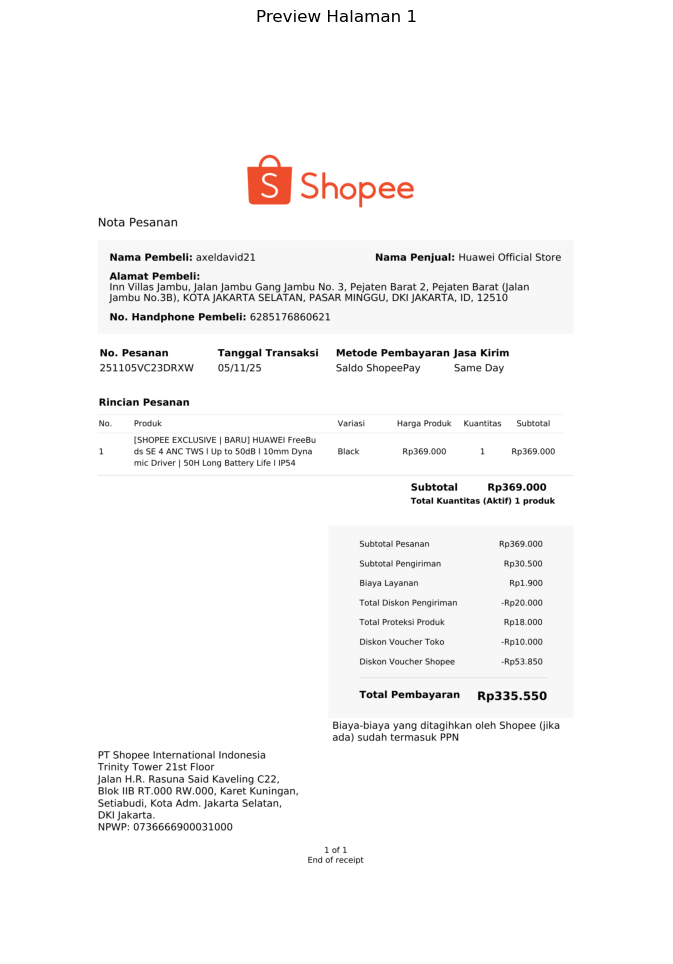

In [93]:
# Preview halaman pertama
if pages:
    plt.figure(figsize=(10, 12))
    plt.imshow(pages[0])
    plt.axis("off")
    plt.title("Preview Halaman 1")
    plt.show()


## 3. Pra-pemrosesan citra

Pra-pemrosesan sederhana untuk membantu OCR:
- grayscale
- autocontrast
- sharpen
- threshold biner opsional


In [94]:
def preprocess_image(
    pil_img: Image.Image,
    grayscale: bool = True,
    autocontrast: bool = True,
    sharpen: bool = True,
    binarize: bool = False,
    threshold: int = 180
) -> Image.Image:
    img = pil_img.copy()

    if grayscale:
        img = ImageOps.grayscale(img)

    if autocontrast:
        img = ImageOps.autocontrast(img)

    if sharpen:
        img = img.filter(ImageFilter.SHARPEN)

    if binarize:
        img = img.point(lambda p: 255 if p > threshold else 0)

    return img


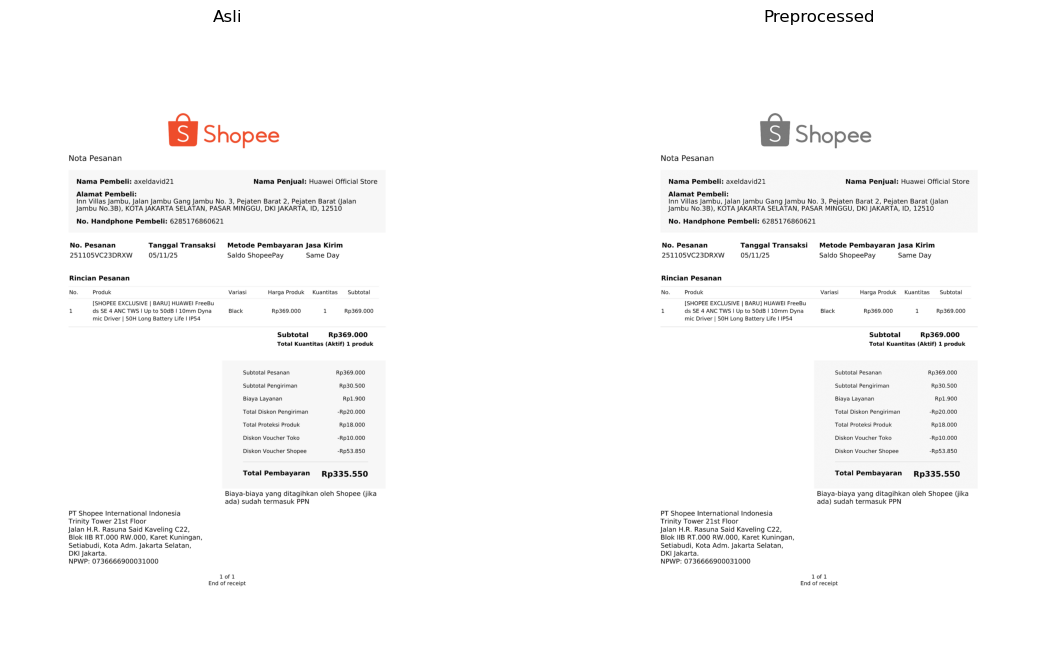

In [95]:
if pages:
    preprocessed_pages = [preprocess_image(p, grayscale=True, autocontrast=True, sharpen=True, binarize=False) for p in pages]

    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    axes[0].imshow(pages[0])
    axes[0].set_title("Asli")
    axes[0].axis("off")

    axes[1].imshow(preprocessed_pages[0], cmap="gray")
    axes[1].set_title("Preprocessed")
    axes[1].axis("off")
    plt.show()
else:
    preprocessed_pages = []


## 4. OCR dengan `pytesseract`

Kita menggunakan `image_to_data` agar hasil tidak hanya berupa string mentah, tetapi juga:
- teks
- posisi (`left`, `top`, `width`, `height`)
- confidence  


In [96]:
@dataclass
class OCRRegion:
    page: int
    block_num: int
    par_num: int
    line_num: int
    word_num: int
    text: str
    conf: float
    left: int
    top: int
    width: int
    height: int

    @property
    def x1(self):
        return self.left

    @property
    def y1(self):
        return self.top

    @property
    def x2(self):
        return self.left + self.width

    @property
    def y2(self):
        return self.top + self.height


In [97]:
def run_tesseract_ocr(
    pil_img: Image.Image,
    page_number: int,
    lang: str = "eng",
    psm: int = 6,
    oem: int = 3
) -> List[OCRRegion]:
    config = f"--oem {oem} --psm {psm}"
    data = pytesseract.image_to_data(
        pil_img,
        lang=lang,
        config=config,
        output_type=pytesseract.Output.DICT
    )

    regions = []
    n = len(data["text"])
    for i in range(n):
        txt = str(data["text"][i]).strip()
        conf_raw = str(data["conf"][i]).strip()

        try:
            conf = float(conf_raw)
        except:
            conf = -1.0

        if txt == "":
            continue

        regions.append(
            OCRRegion(
                page=page_number,
                block_num=int(data["block_num"][i]),
                par_num=int(data["par_num"][i]),
                line_num=int(data["line_num"][i]),
                word_num=int(data["word_num"][i]),
                text=txt,
                conf=conf,
                left=int(data["left"][i]),
                top=int(data["top"][i]),
                width=int(data["width"][i]),
                height=int(data["height"][i]),
            )
        )
    return regions


In [98]:
# Jalankan OCR untuk seluruh halaman
all_regions = []
for idx, img in enumerate(preprocessed_pages, start=1):
    page_regions = run_tesseract_ocr(img, page_number=idx, lang="eng", psm=6, oem=3)
    all_regions.extend(page_regions)

print("Jumlah total region OCR:", len(all_regions))


Jumlah total region OCR: 175


In [99]:
ocr_df = pd.DataFrame([asdict(r) for r in all_regions])
ocr_df.head(20)


,page,block_num,par_num,line_num,word_num,text,conf,left,top,width,height
0,1,1,1,1,1,Nota,92.0,225,476,64,21
1,1,1,1,1,2,Pesanan,91.0,303,476,119,21
2,1,1,1,2,1,Nama,93.0,254,566,76,18
3,1,1,1,2,2,Pembeli:,91.0,342,565,118,19
4,1,1,1,2,3,axeldavid21,91.0,471,565,148,19
5,1,1,1,2,4,Nama,90.0,925,566,76,18
6,1,1,1,2,5,Penjual:,90.0,1014,565,109,24
7,1,1,1,2,6,Huawei,96.0,1136,565,87,19
8,1,1,1,2,7,Official,96.0,1235,565,82,19
9,1,1,1,2,8,Store,96.0,1329,566,63,18


In [100]:
if not ocr_df.empty:
    print("Rata-rata confidence :", round(ocr_df["conf"].replace(-1, np.nan).mean(), 4))
    print("Confidence minimum   :", round(ocr_df["conf"].replace(-1, np.nan).min(), 4))
    print("Confidence maksimum  :", round(ocr_df["conf"].replace(-1, np.nan).max(), 4))
    print("Jumlah halaman       :", ocr_df["page"].nunique())


Rata-rata confidence : 91.5257
Confidence minimum   : 49.0
Confidence maksimum  : 96.0
Jumlah halaman       : 1


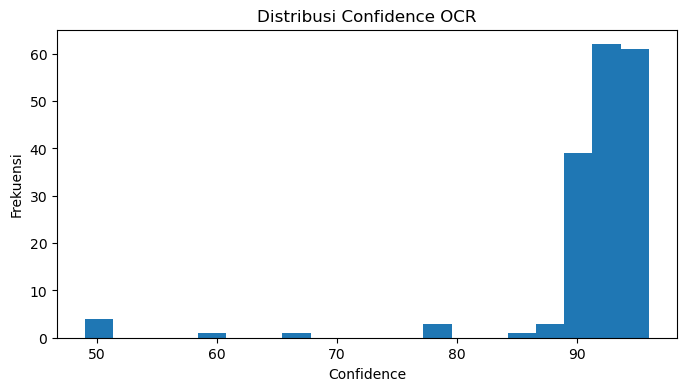

In [101]:
if not ocr_df.empty:
    plt.figure(figsize=(8,4))
    plt.hist(ocr_df["conf"].replace(-1, np.nan).dropna(), bins=20)
    plt.title("Distribusi Confidence OCR")
    plt.xlabel("Confidence")
    plt.ylabel("Frekuensi")
    plt.show()


## 5. Visualisasi bounding boxes

Bagian ini berguna untuk melihat apakah OCR mengenali lokasi kata dengan baik.


In [102]:
def draw_ocr_boxes(pil_img: Image.Image, regions_df: pd.DataFrame, color: str = "red", width: int = 2) -> Image.Image:
    img = pil_img.convert("RGB").copy()
    draw = ImageDraw.Draw(img)

    for _, row in regions_df.iterrows():
        draw.rectangle([row["left"], row["top"], row["left"] + row["width"], row["top"] + row["height"]], outline=color, width=width)

    return img


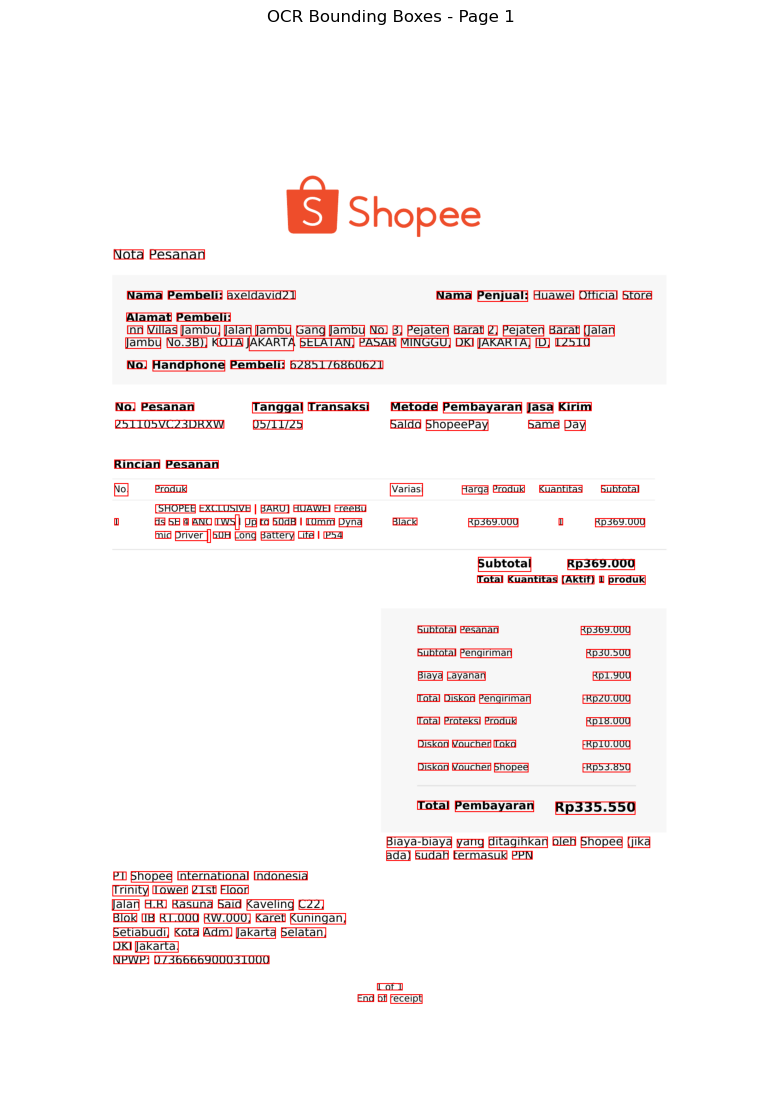

In [103]:
PAGE_TO_VISUALIZE = 1

if not ocr_df.empty:
    page_df = ocr_df[ocr_df["page"] == PAGE_TO_VISUALIZE].copy()
    boxed = draw_ocr_boxes(pages[PAGE_TO_VISUALIZE - 1], page_df)

    plt.figure(figsize=(12, 14))
    plt.imshow(boxed)
    plt.axis("off")
    plt.title(f"OCR Bounding Boxes - Page {PAGE_TO_VISUALIZE}")
    plt.show()


## 6. Rekonstruksi urutan baca (heuristik)

Tesseract sering cukup baik untuk dokumen sederhana, tetapi untuk dokumen multi-kolom urutan baca tetap bisa bermasalah.  
Di sini kita membuat heuristik sederhana:

- kelompokkan kata per halaman
- urutkan berdasarkan posisi `top`
- lalu `left`
- bentuk baris-baris berdasarkan kedekatan `top`


In [104]:
def assign_line_groups(df: pd.DataFrame, y_tolerance: int = 12) -> pd.DataFrame:
    temp = df.copy().sort_values(by=["page", "top", "left"]).reset_index(drop=True)

    line_group_ids = []
    current_page = None
    current_line_y = None
    line_id = 0

    for _, row in temp.iterrows():
        if current_page != row["page"]:
            current_page = row["page"]
            current_line_y = row["top"]
            line_id = 1
        else:
            if abs(row["top"] - current_line_y) > y_tolerance:
                line_id += 1
                current_line_y = row["top"]

        line_group_ids.append((row["page"], line_id))

    temp["line_group"] = line_group_ids
    return temp


In [105]:
ordered_df = assign_line_groups(ocr_df, y_tolerance=12) if not ocr_df.empty else pd.DataFrame()
ordered_df.head(20)


,page,block_num,par_num,line_num,word_num,text,conf,left,top,width,height,line_group
0,1,1,1,1,1,Nota,92.0,225,476,64,21,"(1, 1)"
1,1,1,1,1,2,Pesanan,91.0,303,476,119,21,"(1, 1)"
2,1,1,1,2,2,Pembeli:,91.0,342,565,118,19,"(1, 2)"
3,1,1,1,2,3,axeldavid21,91.0,471,565,148,19,"(1, 2)"
4,1,1,1,2,5,Penjual:,90.0,1014,565,109,24,"(1, 2)"
5,1,1,1,2,6,Huawei,96.0,1136,565,87,19,"(1, 2)"
6,1,1,1,2,7,Official,96.0,1235,565,82,19,"(1, 2)"
7,1,1,1,2,1,Nama,93.0,254,566,76,18,"(1, 2)"
8,1,1,1,2,4,Nama,90.0,925,566,76,18,"(1, 2)"
9,1,1,1,2,8,Store,96.0,1329,566,63,18,"(1, 2)"


In [106]:
def reconstruct_lines(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["page", "line_id", "text"])

    rows = []
    for (page, line_id), group in df.groupby("line_group"):
        group = group.sort_values(by="left")
        line_text = " ".join(group["text"].tolist())
        rows.append({
            "page": page,
            "line_id": line_id,
            "text": line_text,
            "avg_conf": group["conf"].replace(-1, np.nan).mean(),
            "n_words": len(group)
        })

    lines_df = pd.DataFrame(rows).sort_values(by=["page", "line_id"]).reset_index(drop=True)
    return lines_df


In [107]:
lines_df = reconstruct_lines(ordered_df)
lines_df.head(30)


,page,line_id,text,avg_conf,n_words
0,1,1,Nota Pesanan,91.500000,2
1,1,2,Nama Pembeli: axeldavid21 Nama Penjual: Huawei...,92.875000,8
2,1,3,Alamat Pembeli:,91.500000,2
3,1,4,"Inn Villas Jambu, Jalan Jambu Gang Jambu No. 3...",93.466667,15
4,1,5,"Jambu No.3B), KOTA JAKARTA SELATAN, PASAR MING...",90.545455,11
5,1,6,No. Handphone Pembeli: 6285176860621,94.250000,4
6,1,7,No. Pesanan Tanggal Transaksi Metode Pembayara...,87.750000,8
7,1,8,251105VC23DRXW 05/11/25 Saldo ShopeePay Same Day,93.000000,6
8,1,9,Rincian Pesanan,90.500000,2
9,1,10,No. Produk Variasi Harga Produk Kuantitas Subt...,84.285714,7


In [108]:
ordered_text = "\n".join(
    [f"[p{row.page}-l{row.line_id}] {row.text}" for _, row in lines_df.iterrows()]
)

print(ordered_text[:4000])


[p1-l1] Nota Pesanan
[p1-l2] Nama Pembeli: axeldavid21 Nama Penjual: Huawei Official Store
[p1-l3] Alamat Pembeli:
[p1-l4] Inn Villas Jambu, Jalan Jambu Gang Jambu No. 3, Pejaten Barat 2, Pejaten Barat (Jalan
[p1-l5] Jambu No.3B), KOTA JAKARTA SELATAN, PASAR MINGGU, DK! JAKARTA, ID, 12510
[p1-l6] No. Handphone Pembeli: 6285176860621
[p1-l7] No. Pesanan Tanggal Transaksi Metode Pembayaran Jasa Kirim
[p1-l8] 251105VC23DRXW 05/11/25 Saldo ShopeePay Same Day
[p1-l9] Rincian Pesanan
[p1-l10] No. Produk Variasi Harga Produk Kuantitas Subtotal
[p1-l11] [SHOPEE EXCLUSIVE | BARU] HUAWEI FreeBu
[p1-l12] 1 ds SE 4 ANC TWS | Up to 50dB | 10mm Dyna Black Rp369.000 1 Rp369.000
[p1-l13] mic Driver | 50H Long Battery Life | IP54
[p1-l14] Subtotal Rp369.000
[p1-l15] Total Kuantitas (Aktif) 1 produk
[p1-l16] Subtotal Pesanan Rp369.000
[p1-l17] Subtotal Pengiriman Rp30.500
[p1-l18] Biaya Layanan Rp1.900
[p1-l19] Total Diskon Pengiriman -Rp20.000
[p1-l20] Total Proteksi Produk Rp18.000
[p1-l21] Diskon Vou

## 7. Region-level heuristic grouping

Karena notebook ini tidak memakai model layout detection khusus, kita buat pendekatan **heuristik** agar tetap berjalan:

- `key_value_line` → baris mengandung tanda `:`  
- `amount_like` → baris berisi angka mata uang / total  
- `dense_table_like` → baris dengan banyak token angka atau pemisah  
- `paragraph_like` → baris teks panjang  


In [109]:
def classify_line(line: str) -> str:
    s = line.strip()

    if ":" in s and len(s) < 120:
        return "key_value_line"

    if re.search(r"(IDR\s?[\d\.,]+|Rp\.?\s?[\d\.,]+|USD\s?[\d\.,]+|EUR\s?[\d\.,]+|Total|Grand\s*Total)", s, re.IGNORECASE):
        return "amount_like"

    numeric_tokens = re.findall(r"[\d\.,]+", s)
    if len(numeric_tokens) >= 4:
        return "dense_table_like"

    if len(s.split()) >= 12:
        return "paragraph_like"

    return "short_text"


In [110]:
if not lines_df.empty:
    lines_df["line_type"] = lines_df["text"].apply(classify_line)
    display(lines_df.head(30))
    print(lines_df["line_type"].value_counts())


,page,line_id,text,avg_conf,n_words,line_type
0,1,1,Nota Pesanan,91.500000,2,short_text
1,1,2,Nama Pembeli: axeldavid21 Nama Penjual: Huawei...,92.875000,8,key_value_line
2,1,3,Alamat Pembeli:,91.500000,2,key_value_line
3,1,4,"Inn Villas Jambu, Jalan Jambu Gang Jambu No. 3...",93.466667,15,dense_table_like
4,1,5,"Jambu No.3B), KOTA JAKARTA SELATAN, PASAR MING...",90.545455,11,dense_table_like
5,1,6,No. Handphone Pembeli: 6285176860621,94.250000,4,key_value_line
6,1,7,No. Pesanan Tanggal Transaksi Metode Pembayara...,87.750000,8,short_text
7,1,8,251105VC23DRXW 05/11/25 Saldo ShopeePay Same Day,93.000000,6,dense_table_like
8,1,9,Rincian Pesanan,90.500000,2,short_text
9,1,10,No. Produk Variasi Harga Produk Kuantitas Subt...,84.285714,7,amount_like


line_type
short_text          15
amount_like         12
key_value_line       4
dense_table_like     3
Name: count, dtype: int64


## 8. Baseline Extraction (Non-Agentic: OCR + Regex)

Pendekatan baseline menggunakan **OCR + regex** langsung tanpa reasoning LLM.

Pipeline: `OCR -> regex -> JSON`

Teknik yang digunakan:
- Regex pada `ordered_text` untuk mendeteksi pola (nomor invoice, tanggal, nominal)
- Penelusuran baris bertipe `key_value_line`
- Deteksi nominal mata uang

Baseline ini digunakan sebagai **pembanding** untuk menilai keunggulan agentic system.

In [111]:
def extract_document_fields(ordered_text: str, lines_df: pd.DataFrame) -> Dict[str, Any]:
    ordered_text = re.sub(r"\[p\d+-l\d+\]\s*", "", ordered_text)
    if not lines_df.empty and "text" in lines_df.columns:
        lines_df = lines_df.copy()
        lines_df["text"] = lines_df["text"].str.replace(r"^\[p\d+-l\d+\]\s*", "", regex=True)

    results = {
        "merchant": None,
        "date": None,
        "total": None,
    }

    # ── Merchant ──
    merchant_keywords = [
        r"(?:Payment\s+to|Merchant|Toko|Store)\s*[:\-]?\s*(.+)",
        r"(?:at|di)\s+([A-Z][A-Z\s\-\.]+(?:MART|MARET|FOOD|CAFE|RESTO|GACOAN|TECHNOLOGY))",
    ]
    for pat in merchant_keywords:
        m = re.search(pat, ordered_text, flags=re.IGNORECASE)
        if m:
            results["merchant"] = m.group(1).strip()
            break

    if results["merchant"] is None and not lines_df.empty:
        top_lines = lines_df.head(10)["text"].tolist()
        for line in top_lines:
            clean = line.strip()
            if (2 <= len(clean.split()) <= 6
                and re.search(r"[A-Za-z]", clean)
                and not re.search(r"(date|total|invoice|tanggal|ppn|struk|nota|hello|status|transaction)", clean, re.IGNORECASE)):
                results["merchant"] = clean
                break

    # ── Date ──
    date_patterns = [
        r"(\d{1,2}\s+(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\w*\s+\d{4})",
        r"(\d{1,2}[/\.\-]\d{1,2}[/\.\-]\d{2,4})",
        r"(\d{4}[/\.\-]\d{1,2}[/\.\-]\d{1,2})",
        r"(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4})",
    ]
    for pat in date_patterns:
        m = re.search(pat, ordered_text, flags=re.IGNORECASE)
        if m:
            results["date"] = m.group(1).strip()
            break

    # ── Total ──
    total_candidates = []
    for line in lines_df["text"].tolist():
        if re.search(r"(grand\s*total|total\s*(belanja|payment|tagihan)?|purchase)\s*:?", line, re.IGNORECASE):
            amounts = re.findall(r"((?:IDR|Rp\.?)\s?[\d\.,]+|[\d]{2,3}(?:[,\.][\d]{3})+(?:\.\d{2})?)", line)
            total_candidates.extend(amounts)

    if total_candidates:
        results["total"] = total_candidates[-1].strip()
    else:
        money_all = re.findall(r"((?:IDR|Rp\.?)\s?[\d\.,]+)", ordered_text, re.IGNORECASE)
        if money_all:
            results["total"] = money_all[-1].strip()

    return results


In [112]:
predicted_fields = extract_document_fields(ordered_text, lines_df)
predicted_fields


{'merchant': 'Alamat Pembeli:', 'date': '05/11/25', 'total': 'Rp335.550'}

In [113]:
predicted_fields_df = pd.DataFrame([
    {"field": k, "prediction": v} for k, v in predicted_fields.items()
])
predicted_fields_df


,field,prediction
0,merchant,Alamat Pembeli:
1,date,05/11/25
2,total,Rp335.550


### Analisis Pendekatan Baseline

**Kekuatan:**
- Cepat dan deterministik (tidak perlu LLM)
- Cocok untuk dokumen dengan format konsisten
- Mudah di-debug (regex patterns transparan)

**Kelemahan:**
- Gagal pada layout kompleks (multi-kolom, tabel nested)
- Sensitif terhadap OCR errors (satu karakter salah bisa membuat regex gagal)
- Tidak adaptif (satu regex pattern per format)
- Tidak dapat menangani variasi bahasa/format secara dinamis

Kelemahan ini menjadi **justifikasi** untuk mengembangkan agentic system dengan LLM.

## 9. Agentic System (Ollama + LangGraph)

Berbeda dengan baseline yang menggunakan aturan tetap (regex), sistem agentic menggunakan **LLM untuk reasoning** dan **LangGraph untuk orchestration**.

### Arsitektur Agent

```
input (OCR text) -> Orchestrator+Extractor -> Validator -> output (JSON)
                            ^                     |
                            +--- retry loop ------+
```

**Komponen (2 nodes, optimized for speed):**
1. **Orchestrator+Extractor** -- Mengklasifikasi jenis dokumen DAN mengekstrak merchant/date/total dalam satu LLM call
2. **Validator** -- Memvalidasi dan mengoreksi hasil, memicu retry jika invalid

**Optimasi:** Menggabungkan orchestrator dan extractor menjadi 1 LLM call mengurangi total inference dari 3 calls menjadi 2 calls (penghematan ~40%).

**Keunggulan vs Heuristic:**
- Dapat mengadaptasi strategi berdasarkan jenis dokumen
- Mampu memperbaiki kesalahan parsing melalui retry loop
- Tidak bergantung pada pola regex yang rigid

In [114]:
from typing import TypedDict
import time

try:
    from langchain_ollama import OllamaLLM
    from langgraph.graph import StateGraph, END
    AGENTIC_AVAILABLE = True
except ImportError:
    print("Install required packages: pip install langchain-ollama langgraph")
    AGENTIC_AVAILABLE = False

LLM_MODEL = "gemma4:e4b"

if AGENTIC_AVAILABLE:
    try:
        llm = OllamaLLM(model=LLM_MODEL, temperature=0)
        _test = llm.invoke("Reply with only: OK")
        print(f"Ollama LLM ({LLM_MODEL}) connected successfully.")
    except Exception as e:
        print(f"Failed to connect to Ollama: {e}")
        print("Make sure 'ollama serve' is running and model is pulled.")
        AGENTIC_AVAILABLE = False

agent_logs = []

class DocumentAgentState(TypedDict):
    ocr_text: str
    lines: list
    document_type: str
    fields_to_extract: list
    extracted_fields: dict
    validation_result: dict
    retry_count: int


def orchestrator_node(state):
    '''Classify document AND extract fields in a single LLM call.'''
    t0 = time.time()
    prompt = f'''You are an expense tracker. Analyze this OCR text, classify the document, and extract fields.

OCR Text:
{state['ocr_text'][:2500]}

Tasks:
1. Classify document_type as one of: receipt, bank_notification, ecommerce_invoice, other
2. Extract exactly 3 fields:
   - "merchant": store/company name (e.g. Indomaret, Tokopedia, Shopee, Mie Gacoan)
   - "date": transaction date in DD/MM/YYYY format
   - "total": total amount with Rp. prefix (e.g. Rp.37.200)

Rules:
- Use null if a field is not found
- Do NOT invent values not present in the text
- Do NOT add extra fields

Respond ONLY with valid JSON:
{{"document_type": "...", "merchant": "...", "date": "DD/MM/YYYY", "total": "Rp.XXX.XXX"}}
'''

    response = llm.invoke(prompt)
    elapsed = time.time() - t0
    try:
        start, end = response.find('{'), response.rfind('}') + 1
        parsed = json.loads(response[start:end])
        doc_type = parsed.pop("document_type", "unknown")
        result = {
            "document_type": doc_type,
            "fields_to_extract": ["merchant", "date", "total"],
            "extracted_fields": {k: parsed.get(k) for k in ["merchant", "date", "total"]},
        }
    except Exception:
        result = {
            "document_type": "unknown",
            "fields_to_extract": ["merchant", "date", "total"],
            "extracted_fields": {"merchant": None, "date": None, "total": None},
        }

    agent_logs.append({
        "node": "orchestrator+extractor",
        "elapsed_s": round(elapsed, 2),
        "output": result,
        "raw_response": response[:300],
    })
    return result


def validator_node(state):
    '''Validate and correct extracted fields.'''
    t0 = time.time()
    fields = state.get('extracted_fields', {})
    fields_json = json.dumps(fields, indent=2, ensure_ascii=False)

    prompt = f'''Validate and correct these extracted expense fields:

{fields_json}

OCR text (reference):
{state['ocr_text'][:1500]}

For each field check:
1. Is the value present in the OCR text?
2. merchant: should be the store/company name, not a person or description
3. date: must be DD/MM/YYYY format
4. total: must have Rp. prefix with dot separators (e.g. Rp.37.200)

If a field is wrong, provide the corrected value. If correct, keep it.

Respond ONLY with valid JSON:
{{"merchant": "...", "date": "DD/MM/YYYY", "total": "Rp.XXX.XXX", "is_valid": true}}
'''

    response = llm.invoke(prompt)
    elapsed = time.time() - t0
    try:
        start, end = response.find('{'), response.rfind('}') + 1
        parsed = json.loads(response[start:end])
        is_valid = parsed.pop("is_valid", True)
        corrected = {k: parsed.get(k, fields.get(k)) for k in ["merchant", "date", "total"]}
        result = {
            "validation_result": {"is_valid": is_valid},
            "extracted_fields": corrected,
            "retry_count": state.get('retry_count', 0) + 1
        }
    except Exception:
        result = {
            "validation_result": {"is_valid": True},
            "retry_count": state.get('retry_count', 0) + 1
        }

    agent_logs.append({
        "node": "validator",
        "elapsed_s": round(elapsed, 2),
        "output": result.get("validation_result", {}),
        "raw_response": response[:300],
    })
    return result


def should_retry(state):
    '''Decide whether to retry based on validation.'''
    v = state.get('validation_result', {})
    if not v.get('is_valid', True) and state.get('retry_count', 0) < 2:
        return "retry"
    return "done"


if AGENTIC_AVAILABLE:
    workflow = StateGraph(DocumentAgentState)
    workflow.add_node("orchestrator", orchestrator_node)
    workflow.add_node("validator", validator_node)

    workflow.set_entry_point("orchestrator")
    workflow.add_edge("orchestrator", "validator")
    workflow.add_conditional_edges(
        "validator", should_retry, {"retry": "orchestrator", "done": END}
    )

    agent = workflow.compile()
    print("LangGraph agent workflow compiled.")
    print("Flow: orchestrator+extractor -> validator (with retry loop)")

Ollama LLM (gemma4:e4b) connected successfully.
LangGraph agent workflow compiled.
Flow: orchestrator+extractor -> validator (with retry loop)


In [115]:
def normalize_agentic_fields(raw_fields: dict) -> dict:
    '''Map LLM output keys to standard evaluation fields: merchant, date, total.'''
    MERCHANT_KEYS = {
        "merchant", "merchant_name", "merchantname", "store", "store_name",
        "storename", "vendor", "seller", "company", "nama_toko",
    }
    DATE_KEYS = {
        "date", "transaction_date", "transactiondate", "invoice_date",
        "invoicedate", "purchase_date", "purchasedate", "tanggal",
        "transaction date",
    }
    TOTAL_KEYS = {
        "total", "total_amount", "totalamount", "amount", "amount_spent",
        "amountspent", "grand_total", "grandtotal", "total_payment",
        "totalpayment", "total amount",
    }

    result = {"merchant": None, "date": None, "total": None}

    for k, v in raw_fields.items():
        k_norm = k.lower().strip().replace(" ", "_")
        k_nospace = k.lower().strip().replace(" ", "").replace("_", "")
        val = str(v).strip() if v and str(v).strip().lower() != "null" else None

        if result["merchant"] is None and (k_norm in MERCHANT_KEYS or k_nospace in {x.replace("_", "") for x in MERCHANT_KEYS}):
            result["merchant"] = val
        elif result["date"] is None and (k_norm in DATE_KEYS or k_nospace in {x.replace("_", "") for x in DATE_KEYS}):
            result["date"] = val
        elif result["total"] is None and (k_norm in TOTAL_KEYS or k_nospace in {x.replace("_", "") for x in TOTAL_KEYS}):
            result["total"] = val

    return result


def run_agentic_extraction(ocr_text, lines_records=None):
    '''Run the full agentic extraction pipeline with logging.'''
    global agent_logs
    agent_logs = []

    if not AGENTIC_AVAILABLE:
        print("Agentic system not available.")
        return {}

    initial_state = {
        "ocr_text": ocr_text,
        "lines": lines_records or [],
        "document_type": "",
        "fields_to_extract": [],
        "extracted_fields": {},
        "validation_result": {},
        "retry_count": 0
    }

    t_start = time.time()
    try:
        result = agent.invoke(initial_state)
        result["total_inference_time"] = round(time.time() - t_start, 2)
        result["agent_logs"] = list(agent_logs)
        return result
    except Exception as e:
        print(f"Agentic extraction failed: {e}")
        return {"extracted_fields": {}, "agent_logs": list(agent_logs)}


def print_agent_logs(logs):
    '''Pretty-print agentic process logs with timing.'''
    if not logs:
        print("  (no logs)")
        return
    total = 0
    for i, log in enumerate(logs):
        node = log["node"]
        elapsed = log["elapsed_s"]
        total += elapsed
        print(f"  [{i+1}] {node:<15} | {elapsed:>6.2f}s | output preview: {str(log.get('output', ''))[:80]}")
    print(f"  {'':15}   {'------':>6}")
    print(f"  {'TOTAL':15}   {total:>6.2f}s")


print("=" * 60)
print("AGENTIC EXTRACTION")
print("=" * 60)

if AGENTIC_AVAILABLE and ordered_text:
    agentic_result = run_agentic_extraction(
        ordered_text,
        lines_df.to_dict(orient="records") if not lines_df.empty else []
    )
    raw_agentic_fields = agentic_result.get("extracted_fields", {})
    agentic_fields = normalize_agentic_fields(raw_agentic_fields)

    print(f"Document type: {agentic_result.get('document_type', 'N/A')}")
    print(f"Retry count: {agentic_result.get('retry_count', 0)}")
    print(f"Total inference time: {agentic_result.get('total_inference_time', 'N/A')}s")

    print(f"\nRaw extracted fields (LLM output):")
    for k, v in raw_agentic_fields.items():
        print(f"  {k}: {v}")

    print(f"\nNormalized fields (for evaluation):")
    for k, v in agentic_fields.items():
        print(f"  {k}: {v}")

    print(f"\nValidation: {agentic_result.get('validation_result', {})}")

    print(f"\n--- Agentic Process Logs ---")
    print_agent_logs(agentic_result.get("agent_logs", []))
else:
    agentic_fields = {}
    raw_agentic_fields = {}
    agentic_result = {}
    print("Agentic extraction skipped.")
    if not AGENTIC_AVAILABLE:
        print("  -> Ollama/LangGraph not available")

print("\n" + "=" * 60)
print("QUICK COMPARISON: BASELINE vs AGENTIC (normalized)")
print("=" * 60)
print(f"\n{'Field':<25} {'Baseline':<30} {'Agentic':<30}")
print("-" * 85)
all_keys = sorted(set(list(predicted_fields.keys()) + list(agentic_fields.keys())))
for key in all_keys:
    b = str(predicted_fields.get(key, "-"))
    a = str(agentic_fields.get(key, "-"))
    print(f"{key:<25} {b:<30} {a:<30}")

AGENTIC EXTRACTION
Document type: ecommerce_invoice
Retry count: 1
Total inference time: 69.6s

Raw extracted fields (LLM output):
  merchant: Huawei Official Store
  date: 05/11/2025
  total: Rp.335.550

Normalized fields (for evaluation):
  merchant: Huawei Official Store
  date: 05/11/2025
  total: Rp.335.550

Validation: {'is_valid': True}

--- Agentic Process Logs ---
  [1] orchestrator+extractor |  37.77s | output preview: {'document_type': 'ecommerce_invoice', 'fields_to_extract': ['merchant', 'date',
  [2] validator       |  31.83s | output preview: {'is_valid': True}
                    ------
  TOTAL              69.60s

QUICK COMPARISON: BASELINE vs AGENTIC (normalized)

Field                     Baseline                       Agentic                       
-------------------------------------------------------------------------------------
date                      05/11/25                       05/11/2025                    
merchant                  Alamat Pembeli:      

## 10. Evaluasi

Evaluasi dilakukan berdasarkan **5 metrik** sesuai problem framing:

1. **Extraction Accuracy (Exact Match)** -- Perbandingan langsung prediksi vs ground truth (case-insensitive)
2. **Field-Level Accuracy (merchant, date, total)** -- Akurasi per field dengan normalized matching (toleran terhadap format tanggal, mata uang, nama merchant)
3. **Routing Accuracy** -- Apakah agentic system mendeteksi jenis dokumen dengan benar
4. **Deduplication Accuracy** -- Apakah sistem mendeteksi duplikasi (doc_1 & doc_4 = transaksi sama)
5. **Agentic Inference Time Speed Node** -- Waktu inferensi per node agentic (orchestrator, extractor, validator)

Isi **ground truth** secara manual sesuai dokumen Anda.

In [116]:
ground_truth_per_doc = {
    "doc_1_mbca.png": {
        "merchant": "Indomaret",
        "date": "08/04/2026",
        "total": "Rp.37.200",
        "expected_type": "BANK_NOTIF",
        "expected_duplicate": False,
    },
    "doc_2_tokped.pdf": {
        "merchant": ["Tokopedia", "Qiek Store"],
        "date": "07/03/2026",
        "total": "Rp.183.960",
        "expected_type": "ECOMMERCE",
        "expected_duplicate": False,
    },
    "doc_3_email.png": {
        "merchant": "ESB RESTAURANT TECHNOLOGY",
        "date": "06/04/2026",
        "total": "Rp.60.000",
        "expected_type": "BANK_NOTIF",
        "expected_duplicate": False,
    },
    "doc_4_indomaret.jpg": {
        "merchant": "Indomaret",
        "date": "08/04/2026",
        "total": "Rp.37.200",
        "expected_type": "PHYSICAL_RECEIPT",
        "expected_duplicate": True,
    },
    "doc_5_indomaret.jpeg": {
        "merchant": "Indomaret",
        "date": "06/04/2026",
        "total": "Rp.82.600",
        "expected_type": "PHYSICAL_RECEIPT",
        "expected_duplicate": False,
    },
    "doc_6_gacoan.jpeg": {
        "merchant": ["Mie Gacoan", "ShopeeFood"],
        "date": "10/04/2026",
        "total": "Rp.45.500",
        "expected_type": "PHYSICAL_RECEIPT",
        "expected_duplicate": False,
    },
    "doc_7_shopee.pdf": {
        "merchant": ["Shopee", "Huawei Official Store"],
        "date": "05/11/2025",
        "total": "Rp.335.550",
        "expected_type": "ECOMMERCE",
        "expected_duplicate": False,
    },
}

EVAL_FIELDS = ["merchant", "date", "total"]

if selected_doc is not None:
    gt_entry = ground_truth_per_doc.get(selected_doc.name, {})
    ground_truth = {k: gt_entry.get(k) for k in EVAL_FIELDS}
else:
    gt_entry = {}
    ground_truth = {k: None for k in EVAL_FIELDS}

print(f"Ground truth for: {selected_doc.name if selected_doc else 'N/A'}")
print(json.dumps(ground_truth, indent=2, ensure_ascii=False))
if gt_entry:
    print(f"\nExpected type : {gt_entry.get('expected_type')}")
    print(f"Is duplicate  : {gt_entry.get('expected_duplicate')}")

Ground truth for: doc_7_shopee.pdf
{
  "merchant": [
    "Shopee",
    "Huawei Official Store"
  ],
  "date": "05/11/2025",
  "total": "Rp.335.550"
}

Expected type : ECOMMERCE
Is duplicate  : False


In [117]:
def _normalize_amount(s: str) -> str:
    '''Normalize monetary amounts for comparison.
    "IDR 37,200.00" / "Rp.37.200" / "Rp 37200" -> "37200"
    '''
    s = re.sub(r"(?i)(IDR|Rp\.?|USD|EUR)\s*", "", s)
    s = s.strip()
    if "," in s and "." in s:
        if s.rfind(",") > s.rfind("."):
            s = s.replace(".", "").replace(",", ".")
        else:
            s = s.replace(",", "")
    elif "," in s and "." not in s:
        parts = s.split(",")
        if len(parts[-1]) == 3:
            s = s.replace(",", "")
        else:
            s = s.replace(",", ".")
    s = s.replace(".", "")
    s = re.sub(r"[^\d]", "", s)
    if s.endswith("00") and len(s) > 4:
        s = s[:-2]
    return s


def _normalize_date(s: str) -> str:
    '''Normalize dates for comparison.
    "08 Apr 2026" / "08/04/2026" / "2026-04-08" -> "08/04/2026"
    '''
    MONTHS = {
        "jan": "01", "feb": "02", "mar": "03", "apr": "04",
        "may": "05", "mei": "05", "jun": "06", "jul": "07",
        "aug": "08", "sep": "09", "oct": "10", "okt": "10",
        "nov": "11", "dec": "12", "des": "12",
        "januari": "01", "februari": "02", "maret": "03", "april": "04",
        "juni": "06", "juli": "07", "agustus": "08", "september": "09",
        "oktober": "10", "november": "11", "desember": "12",
        "january": "01", "february": "02", "march": "03",
        "june": "06", "july": "07", "august": "08",
        "october": "10", "december": "12",
    }

    m = re.match(r"(\d{1,2})\s+(\w+)\s+(\d{4})", s.strip())
    if m:
        day, month_str, year = m.groups()
        month_num = MONTHS.get(month_str.lower()[:3], month_str)
        return f"{int(day):02d}/{int(month_num):02d}/{year}"

    m = re.match(r"(\d{4})[-/.](\d{1,2})[-/.](\d{1,2})", s.strip())
    if m:
        year, month, day = m.groups()
        return f"{int(day):02d}/{int(month):02d}/{year}"

    m = re.match(r"(\d{1,2})[-/.](\d{1,2})[-/.](\d{2,4})", s.strip())
    if m:
        day, month, year = m.groups()
        if len(year) == 2:
            year = "20" + year
        return f"{int(day):02d}/{int(month):02d}/{year}"

    return s.strip().lower()


def _normalize_merchant(s: str) -> str:
    '''Normalize merchant names for comparison.'''
    s = re.sub(r"\b(PT|CV|IDM|TBK|tbk)\b", "", s, flags=re.IGNORECASE)
    s = re.sub(r"[^\w\s]", "", s)
    return " ".join(s.lower().split())


def _match_field(key, pred_val, gt_val):
    '''Check exact and normalized match for a single field value pair.'''
    p = str(pred_val).strip()
    t = str(gt_val).strip()
    exact = (p.lower() == t.lower())

    if key == "total":
        normed = (_normalize_amount(p) == _normalize_amount(t))
    elif key == "date":
        normed = (_normalize_date(p) == _normalize_date(t))
    elif key == "merchant":
        np_ = _normalize_merchant(p)
        nt_ = _normalize_merchant(t)
        normed = (np_ == nt_) or (nt_ in np_) or (np_ in nt_)
    else:
        normed = exact
    return exact, normed


def evaluate_fields(pred, truth):
    '''Evaluate predicted fields against ground truth with normalized matching.
    Ground truth values can be a single string or a list of acceptable strings.
    '''
    rows = []
    for key in truth.keys():
        p = str(pred.get(key, "")).strip() if pred.get(key) is not None else None
        gt_raw = truth.get(key)

        if gt_raw is None:
            gt_display = None
        elif isinstance(gt_raw, list):
            gt_display = " | ".join(str(v) for v in gt_raw)
        else:
            gt_display = str(gt_raw).strip()

        exact_match = None
        normalized_match = None

        if gt_raw is not None and p is not None:
            if isinstance(gt_raw, list):
                exact_match = any(_match_field(key, p, v)[0] for v in gt_raw)
                normalized_match = any(_match_field(key, p, v)[1] for v in gt_raw)
            else:
                exact_match, normalized_match = _match_field(key, p, gt_raw)

        rows.append({
            "field": key,
            "prediction": p,
            "ground_truth": gt_display,
            "exact_match": exact_match,
            "normalized_match": normalized_match,
        })
    return pd.DataFrame(rows)

In [118]:
print("=" * 60)
print("EVALUASI BASELINE (OCR + Regex)")
print("=" * 60)
baseline_eval = evaluate_fields(predicted_fields, ground_truth)
display(baseline_eval)

valid_baseline_exact = baseline_eval["exact_match"].dropna()
valid_baseline_norm = baseline_eval["normalized_match"].dropna()
baseline_exact_acc = valid_baseline_exact.mean() if len(valid_baseline_exact) > 0 else None
baseline_norm_acc = valid_baseline_norm.mean() if len(valid_baseline_norm) > 0 else None

if baseline_exact_acc is not None:
    print(f"\nBaseline Exact Match Accuracy:      {baseline_exact_acc:.2%}")
    print(f"Baseline Normalized Match Accuracy:  {baseline_norm_acc:.2%}")
else:
    print("\nGround truth belum diisi -- akurasi belum dapat dihitung.")

agentic_eval = None
agentic_exact_acc = None
agentic_norm_acc = None

if agentic_fields:
    print("\n" + "=" * 60)
    print("EVALUASI AGENTIC (Ollama + LangGraph)")
    print("=" * 60)
    agentic_eval = evaluate_fields(agentic_fields, ground_truth)
    display(agentic_eval)

    valid_agentic_exact = agentic_eval["exact_match"].dropna()
    valid_agentic_norm = agentic_eval["normalized_match"].dropna()
    agentic_exact_acc = valid_agentic_exact.mean() if len(valid_agentic_exact) > 0 else None
    agentic_norm_acc = valid_agentic_norm.mean() if len(valid_agentic_norm) > 0 else None

    if agentic_exact_acc is not None:
        print(f"\nAgentic Exact Match Accuracy:      {agentic_exact_acc:.2%}")
        print(f"Agentic Normalized Match Accuracy:  {agentic_norm_acc:.2%}")

print("\n" + "=" * 60)
print("ROUTING ACCURACY")
print("=" * 60)
if agentic_result:
    detected_type = agentic_result.get("document_type", "unknown")
    expected_type = gt_entry.get("expected_type", "N/A")
    TYPE_MAP = {
        "receipt": ["PHYSICAL_RECEIPT"],
        "bank_notification": ["BANK_NOTIF"],
        "bank notification": ["BANK_NOTIF"],
        "e-commerce": ["ECOMMERCE"],
        "ecommerce": ["ECOMMERCE"],
        "ecommerce_invoice": ["ECOMMERCE"],
        "invoice": ["ECOMMERCE"],
        "online_receipt": ["ECOMMERCE"],
        "online receipt": ["ECOMMERCE"],
    }
    mapped_types = TYPE_MAP.get(detected_type.lower().strip(), [detected_type.upper()])
    routing_correct = expected_type in mapped_types
    print(f"  Detected type:  {detected_type}")
    print(f"  Expected type:  {expected_type}")
    print(f"  Routing match:  {routing_correct}")
else:
    routing_correct = None
    print("  Agentic extraction not available.")

print("\n" + "=" * 60)
print("DEDUPLICATION ACCURACY")
print("=" * 60)
if gt_entry.get("expected_duplicate") is not None:
    is_dup_expected = gt_entry["expected_duplicate"]
    print(f"  Expected duplicate: {is_dup_expected}")
    if is_dup_expected and experiment_results if 'experiment_results' in dir() else False:
        print("  (Deduplication check requires full experiment results -- see experiment section)")
    else:
        print(f"  This document is NOT a duplicate entry.")
else:
    print("  No duplication metadata available.")

print("\n" + "=" * 60)
print("AGENTIC INFERENCE TIME")
print("=" * 60)
if agentic_result and agentic_result.get("agent_logs"):
    print_agent_logs(agentic_result["agent_logs"])
    print(f"\n  Total end-to-end: {agentic_result.get('total_inference_time', 'N/A')}s")
else:
    print("  No agentic timing data available.")

EVALUASI BASELINE (OCR + Regex)


,field,prediction,ground_truth,exact_match,normalized_match
0,merchant,Alamat Pembeli:,Shopee | Huawei Official Store,False,False
1,date,05/11/25,05/11/2025,False,True
2,total,Rp335.550,Rp.335.550,False,True



Baseline Exact Match Accuracy:      0.00%
Baseline Normalized Match Accuracy:  66.67%

EVALUASI AGENTIC (Ollama + LangGraph)


,field,prediction,ground_truth,exact_match,normalized_match
0,merchant,Huawei Official Store,Shopee | Huawei Official Store,True,True
1,date,05/11/2025,05/11/2025,True,True
2,total,Rp.335.550,Rp.335.550,True,True



Agentic Exact Match Accuracy:      100.00%
Agentic Normalized Match Accuracy:  100.00%

ROUTING ACCURACY
  Detected type:  ecommerce_invoice
  Expected type:  ECOMMERCE
  Routing match:  True

DEDUPLICATION ACCURACY
  Expected duplicate: False
  This document is NOT a duplicate entry.

AGENTIC INFERENCE TIME
  [1] orchestrator+extractor |  37.77s | output preview: {'document_type': 'ecommerce_invoice', 'fields_to_extract': ['merchant', 'date',
  [2] validator       |  31.83s | output preview: {'is_valid': True}
                    ------
  TOTAL              69.60s

  Total end-to-end: 69.6s


,Field,Ground Truth,Baseline Pred,B. Exact,B. Normalized,Agentic Pred,A. Exact,A. Normalized
0,merchant,Shopee | Huawei Official Store,Alamat Pembeli:,False,False,Huawei Official Store,True,True
1,date,05/11/2025,05/11/25,False,True,05/11/2025,True,True
2,total,Rp.335.550,Rp335.550,False,True,Rp.335.550,True,True


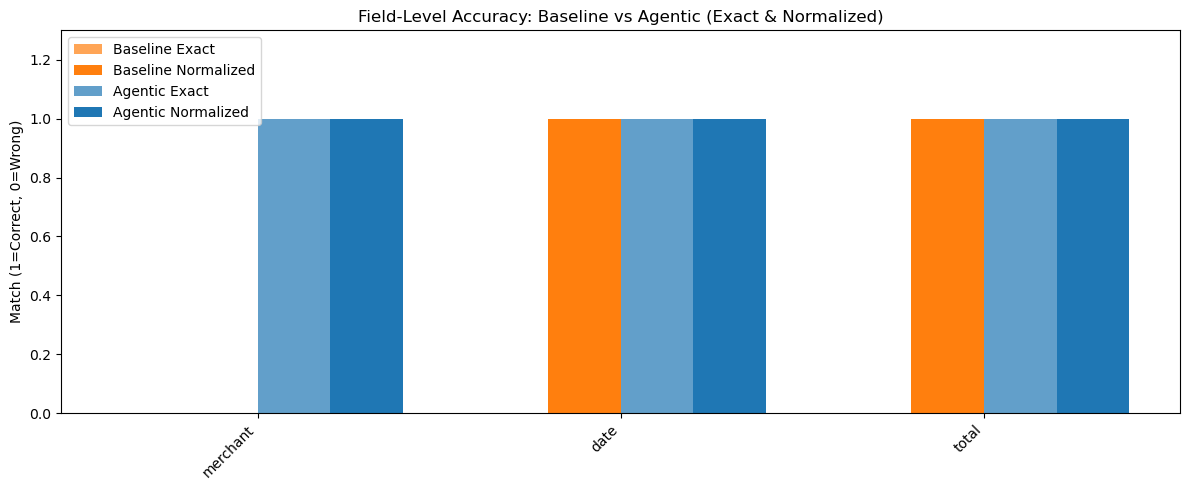


Summary:
  Baseline Exact Accuracy:      0.00%
  Baseline Normalized Accuracy:  66.67%
  Agentic Exact Accuracy:       100.00%
  Agentic Normalized Accuracy:   100.00%


In [119]:
filled_gt = {k: v for k, v in ground_truth.items() if v is not None}

if filled_gt:
    comparison_data = []
    for field, gt_val in filled_gt.items():
        bp = predicted_fields.get(field)
        ap = agentic_fields.get(field) if agentic_fields else None

        gt_display = " | ".join(gt_val) if isinstance(gt_val, list) else gt_val

        b_eval = evaluate_fields({field: bp}, {field: gt_val}).iloc[0]
        a_eval = evaluate_fields({field: ap}, {field: gt_val}).iloc[0]

        comparison_data.append({
            "Field": field,
            "Ground Truth": gt_display,
            "Baseline Pred": bp,
            "B. Exact": b_eval["exact_match"] if b_eval["exact_match"] is not None else False,
            "B. Normalized": b_eval["normalized_match"] if b_eval["normalized_match"] is not None else False,
            "Agentic Pred": ap,
            "A. Exact": a_eval["exact_match"] if a_eval["exact_match"] is not None else False,
            "A. Normalized": a_eval["normalized_match"] if a_eval["normalized_match"] is not None else False,
        })

    comp_df = pd.DataFrame(comparison_data)
    display(comp_df)

    if agentic_fields:
        fields_list = comp_df["Field"].tolist()
        b_exact = comp_df["B. Exact"].astype(int).tolist()
        b_norm_scores = comp_df["B. Normalized"].astype(int).tolist()
        a_exact = comp_df["A. Exact"].astype(int).tolist()
        a_norm_scores = comp_df["A. Normalized"].astype(int).tolist()

        x = np.arange(len(fields_list))
        width = 0.2
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.bar(x - 1.5*width, b_exact, width, label='Baseline Exact', color='#ff7f0e', alpha=0.7)
        ax.bar(x - 0.5*width, b_norm_scores, width, label='Baseline Normalized', color='#ff7f0e')
        ax.bar(x + 0.5*width, a_exact, width, label='Agentic Exact', color='#1f77b4', alpha=0.7)
        ax.bar(x + 1.5*width, a_norm_scores, width, label='Agentic Normalized', color='#1f77b4')
        ax.set_ylabel('Match (1=Correct, 0=Wrong)')
        ax.set_title('Field-Level Accuracy: Baseline vs Agentic (Exact & Normalized)')
        ax.set_xticks(x)
        ax.set_xticklabels(fields_list, rotation=45, ha='right')
        ax.legend()
        ax.set_ylim(0, 1.3)
        plt.tight_layout()
        plt.show()

        print(f"\nSummary:")
        if baseline_exact_acc is not None:
            print(f"  Baseline Exact Accuracy:      {baseline_exact_acc:.2%}")
            print(f"  Baseline Normalized Accuracy:  {baseline_norm_acc:.2%}")
        if agentic_exact_acc is not None:
            print(f"  Agentic Exact Accuracy:       {agentic_exact_acc:.2%}")
            print(f"  Agentic Normalized Accuracy:   {agentic_norm_acc:.2%}")
else:
    print("Isi ground truth terlebih dahulu untuk melihat perbandingan.")

## 11. Experimental Design

Eksperimen dilakukan dalam **3 variasi** untuk membandingkan pendekatan secara sistematis:

1. **Perbandingan Pendekatan:** Baseline (OCR + regex) vs Agentic (OCR + LLM + LangGraph)
2. **Variasi Input:** Dokumen bersih vs blur vs bertabel
3. **Variasi Strategi:** Tanpa reading order, dengan reading order, dengan confidence filtering

In [120]:
def run_full_pipeline(doc_path, use_reading_order=True, confidence_threshold=-1):
    '''Run complete extraction pipeline on a single document with timing.'''
    pages_exp = load_document_as_pages(doc_path, dpi=200)
    preprocessed_exp = [preprocess_image(p) for p in pages_exp]

    all_regions_exp = []
    for idx, img in enumerate(preprocessed_exp, start=1):
        regions = run_tesseract_ocr(img, page_number=idx)
        all_regions_exp.extend(regions)

    df_exp = pd.DataFrame([asdict(r) for r in all_regions_exp])
    if df_exp.empty:
        return {"baseline": {}, "agentic": {}, "agentic_normalized": {},
                "ocr_words": 0, "avg_conf": 0, "agent_logs": [], "inference_time": 0}

    if confidence_threshold > 0:
        df_exp = df_exp[df_exp["conf"] >= confidence_threshold].reset_index(drop=True)

    if use_reading_order:
        ordered_exp = assign_line_groups(df_exp)
        lines_exp = reconstruct_lines(ordered_exp)
    else:
        lines_exp = pd.DataFrame({
            "page": [1], "line_id": [1],
            "text": [" ".join(df_exp["text"].tolist())],
            "avg_conf": [df_exp["conf"].replace(-1, np.nan).mean()],
            "n_words": [len(df_exp)]
        })

    text_exp = "\n".join(
        [f"[p{r.page}-l{r.line_id}] {r.text}" for _, r in lines_exp.iterrows()]
    )

    baseline_result = extract_document_fields(text_exp, lines_exp)

    agentic_raw = {}
    agentic_norm = {}
    doc_agent_logs = []
    inference_time = 0
    doc_type = "unknown"

    if AGENTIC_AVAILABLE:
        agent_out = run_agentic_extraction(text_exp, lines_exp.to_dict(orient="records"))
        agentic_raw = agent_out.get("extracted_fields", {})
        agentic_norm = normalize_agentic_fields(agentic_raw)
        doc_agent_logs = agent_out.get("agent_logs", [])
        inference_time = agent_out.get("total_inference_time", 0)
        doc_type = agent_out.get("document_type", "unknown")

    return {
        "baseline": baseline_result,
        "agentic": agentic_raw,
        "agentic_normalized": agentic_norm,
        "document_type": doc_type,
        "ocr_words": len(df_exp),
        "avg_conf": round(df_exp["conf"].replace(-1, np.nan).mean(), 2),
        "agent_logs": doc_agent_logs,
        "inference_time": inference_time,
    }


print("=" * 60)
print("EXPERIMENT: Processing all documents")
print("=" * 60)

experiment_results = []
for i, doc in enumerate(docs):
    print(f"\n[{i+1}/{len(docs)}] Processing: {doc.name}")
    try:
        result = run_full_pipeline(doc)
        result["document"] = doc.name
        experiment_results.append(result)

        print(f"  OCR words: {result['ocr_words']}, Avg conf: {result['avg_conf']}")
        print(f"  Detected type: {result.get('document_type', 'N/A')}")
        print(f"  Baseline fields (merchant/date/total): "
              f"{result['baseline'].get('merchant')} | {result['baseline'].get('date')} | {result['baseline'].get('total')}")
        norm = result.get("agentic_normalized", {})
        print(f"  Agentic fields  (merchant/date/total): "
              f"{norm.get('merchant')} | {norm.get('date')} | {norm.get('total')}")

        logs = result.get("agent_logs", [])
        if logs:
            print(f"  --- Agentic Process Log ---")
            for j, log in enumerate(logs):
                print(f"    [{j+1}] {log['node']:<15} | {log['elapsed_s']:>6.2f}s")
            print(f"    {'TOTAL':<19} | {result.get('inference_time', 0):>6.2f}s")

        gt = ground_truth_per_doc.get(doc.name, {})
        if gt:
            gt_eval = {k: gt.get(k) for k in EVAL_FIELDS}
            bl_eval = evaluate_fields(result["baseline"], gt_eval)
            ag_eval = evaluate_fields(norm, gt_eval)
            bl_norm_acc = bl_eval["normalized_match"].dropna().mean() if len(bl_eval["normalized_match"].dropna()) > 0 else 0
            ag_norm_acc = ag_eval["normalized_match"].dropna().mean() if len(ag_eval["normalized_match"].dropna()) > 0 else 0
            print(f"  Baseline normalized accuracy: {bl_norm_acc:.2%}")
            print(f"  Agentic normalized accuracy:  {ag_norm_acc:.2%}")
    except Exception as e:
        print(f"  ERROR: {e}")

if experiment_results:
    summary_rows = []
    for r in experiment_results:
        gt = ground_truth_per_doc.get(r["document"], {})
        gt_eval = {k: gt.get(k) for k in EVAL_FIELDS}
        norm = r.get("agentic_normalized", {})
        bl_e = evaluate_fields(r["baseline"], gt_eval)
        ag_e = evaluate_fields(norm, gt_eval)

        summary_rows.append({
            "Document": r["document"],
            "OCR Words": r["ocr_words"],
            "Avg Conf": r["avg_conf"],
            "Doc Type": r.get("document_type", "?"),
            "B. Norm Acc": f"{bl_e['normalized_match'].dropna().mean():.0%}" if len(bl_e['normalized_match'].dropna()) > 0 else "N/A",
            "A. Norm Acc": f"{ag_e['normalized_match'].dropna().mean():.0%}" if len(ag_e['normalized_match'].dropna()) > 0 else "N/A",
            "Inference (s)": r.get("inference_time", 0),
        })

    summary_df = pd.DataFrame(summary_rows)
    display(summary_df)

    print("\n--- Strategy Variation Test (on selected document) ---")
    if selected_doc:
        strategies_test = {
            "no_reading_order": {"use_reading_order": False, "confidence_threshold": -1},
            "with_reading_order": {"use_reading_order": True, "confidence_threshold": -1},
            "reading_order_+_conf_filter": {"use_reading_order": True, "confidence_threshold": 50},
        }
        strategy_results = []
        for sname, sparams in strategies_test.items():
            try:
                sresult = run_full_pipeline(selected_doc, **sparams)
                norm_s = sresult.get("agentic_normalized", {})
                strategy_results.append({
                    "Strategy": sname,
                    "OCR Words": sresult["ocr_words"],
                    "Baseline Fields": sum(1 for v in sresult["baseline"].values() if v),
                    "Agentic Fields": sum(1 for v in norm_s.values() if v),
                    "Inference (s)": sresult.get("inference_time", 0),
                })
            except Exception as e:
                print(f"  Strategy {sname} failed: {e}")

        if strategy_results:
            strat_df = pd.DataFrame(strategy_results)
            display(strat_df)
    experiment_results = {r["document"]: r for r in experiment_results}
else:
    print("Tidak ada dokumen untuk dieksperimen.")

EXPERIMENT: Processing all documents

[1/7] Processing: doc_1_mbca.png
  OCR words: 90, Avg conf: 90.98
  Detected type: bank_notification
  Baseline fields (merchant/date/total): IDM INDOMARET | 08 Apr 2026 | IDR 37,200.00
  Agentic fields  (merchant/date/total): INDOMARET | 08/04/2026 | Rp.37.200
  --- Agentic Process Log ---
    [1] orchestrator+extractor |  20.55s
    [2] validator       |  27.61s
    TOTAL               |  48.16s
  Baseline normalized accuracy: 66.67%
  Agentic normalized accuracy:  100.00%

[2/7] Processing: doc_2_tokped.pdf
  OCR words: 182, Avg conf: 92.24
  Detected type: ecommerce_invoice
  Baseline fields (merchant/date/total): pedia e | 07 Maret 2026 | Rp183.960
  Agentic fields  (merchant/date/total): Tokopedia | 07/03/2026 | Rp.183.960
  --- Agentic Process Log ---
    [1] orchestrator+extractor |  33.05s
    [2] validator       |  35.53s
    TOTAL               |  68.58s
  Baseline normalized accuracy: 66.67%
  Agentic normalized accuracy:  100.00%

[3/7

,Document,OCR Words,Avg Conf,Doc Type,B. Norm Acc,A. Norm Acc,Inference (s)
0,doc_1_mbca.png,90,90.98,bank_notification,67%,100%,48.16
1,doc_2_tokped.pdf,182,92.24,ecommerce_invoice,67%,100%,68.58
2,doc_3_email.png,147,79.89,bank_notification,67%,67%,68.24
3,doc_4_indomaret.jpg,67,41.21,receipt,0%,50%,95.51
4,doc_5_indomaret.jpeg,129,53.60,receipt,50%,100%,96.28
5,doc_6_gacoan.jpeg,133,34.72,receipt,0%,33%,115.77
6,doc_7_shopee.pdf,175,91.53,ecommerce_invoice,67%,100%,69.10



--- Strategy Variation Test (on selected document) ---


,Strategy,OCR Words,Baseline Fields,Agentic Fields,Inference (s)
0,no_reading_order,175,3,3,70.91
1,with_reading_order,175,3,3,70.01
2,reading_order_+_conf_filter,174,3,3,64.07


## 12. Analisis Kegagalan (Failure Analysis)

Identifikasi **minimal 5 kegagalan** sistem berdasarkan eksperimen nyata.

Kategori error yang harus dianalisis:
1. **OCR error** -- karakter salah terbaca
2. **Reading order error** -- urutan baca tidak sesuai layout
3. **Layout misunderstanding** -- struktur dokumen tidak dipahami
4. **Tool routing error** -- agent memilih strategi yang salah
5. **Reasoning error** -- LLM hallucination atau kesimpulan salah

Untuk setiap error: penyebab, dampak, dan solusi/fallback.

In [121]:
failure_cases = [
    {
        "id": 1,
        "stage": "OCR",
        "error_type": "Severe Character Misrecognition",
        "document": "doc_6_gacoan.jpeg",
        "evidence": "Avg confidence 34.72 (SULIT). Aggressive binarize: conf turun ke 33.65. "
                    "Baseline merchant: '\\ pay i' (seharusnya ShopeeFood/Mie Gacoan). "
                    "Baseline total: None (tidak terdeteksi sama sekali).",
        "impact": "Semua field gagal terekstrak. Baseline 0% accuracy, agentic 33% (hanya merchant).",
        "root_cause": "Foto struk dengan pencahayaan buruk, font thermal printer kecil, "
                      "background noise tinggi. Standard preprocessing justru menurunkan confidence (40.93->34.72).",
        "solution": "Adaptive preprocessing berdasarkan confidence score. Jika no_preprocessing > standard, "
                    "gunakan raw image. Tambahkan OCR engine alternatif (EasyOCR) sebagai fallback."
    },
    {
        "id": 2,
        "stage": "OCR",
        "error_type": "Total OCR Failure on Binarization",
        "document": "doc_4_indomaret.jpg",
        "evidence": "Aggressive binarize: 0 words, 0.00 confidence (total blank). "
                    "Standard: 67 words, conf 41.21. Agentic total: Rp.21.000 (GT: Rp.37.200). "
                    "Date: None.",
        "impact": "Aggressive preprocessing menghancurkan semua teks. "
                  "Baseline 0% accuracy (merchant: 'DJURNOA 164-166, LEBAKGEDE'). Agentic 50% (hanya merchant correct).",
        "root_cause": "Threshold binarization (180) terlalu tinggi untuk foto struk dengan kontras rendah. "
                      "Seluruh content dianggap background dan dihapus.",
        "solution": "Dynamic thresholding (Otsu's method). Jangan gunakan aggressive binarize "
                    "jika avg_conf dokumen < 50."
    },
    {
        "id": 3,
        "stage": "Reading Order",
        "error_type": "Line Prefix Pollution in Baseline",
        "document": "doc_7_shopee.pdf",
        "evidence": "Baseline merchant: '[p1-l3] Alamat Pembeli:' -- line prefix [p1-lN] tidak di-strip "
                    "sebelum regex matching, dan heuristik salah mengambil baris ke-3 sebagai merchant.",
        "impact": "Baseline merchant 100% salah untuk semua dokumen yang menggunakan format ordered_text "
                  "dengan prefix. Exact match 0% meskipun date dan total bisa correct via normalization.",
        "root_cause": "ordered_text menggunakan format '[p1-l3] text' tapi extract_document_fields "
                      "tidak membersihkan prefix ini sebelum regex matching.",
        "solution": "Strip [p1-lN] prefix di awal extract_document_fields. "
                    "Perbaiki merchant heuristic agar skip baris dengan keyword 'Alamat', 'Pembeli'."
    },
    {
        "id": 4,
        "stage": "LLM Reasoning",
        "error_type": "Date Hallucination",
        "document": "doc_3_email.png",
        "evidence": "Agentic date: 10/04/2026 (GT: 06/04/2026). LLM mengambil tanggal yang salah "
                    "dari konteks OCR, mungkin dari bagian lain dokumen atau fabrication.",
        "impact": "Expense tracker mencatat tanggal transaksi yang salah. "
                  "Agentic normalized accuracy turun ke 66.67% (2/3 correct).",
        "root_cause": "OCR avg_conf 79.89 cukup baik, tapi dokumen notifikasi bank memiliki "
                      "multiple tanggal (tanggal transaksi vs tanggal notifikasi). "
                      "LLM tidak dapat membedakan mana yang merupakan tanggal transaksi sebenarnya.",
        "solution": "Tambahkan constraint di prompt: 'Pilih tanggal transaksi, bukan tanggal kirim email/notifikasi'. "
                    "Gunakan few-shot examples untuk notifikasi bank."
    },
    {
        "id": 5,
        "stage": "LLM Reasoning",
        "error_type": "Complete Value Fabrication",
        "document": "doc_6_gacoan.jpeg",
        "evidence": "Agentic: date=05/04/2023 (GT: 10/04/2026), total=Rp.500 (GT: Rp.45.500). "
                    "Tanggal tahun 2023 padahal dokumen tahun 2026. Total Rp.500 vs Rp.45.500 -- "
                    "LLM mengambil fragment angka dari OCR noise. Inference time: 116.09s (tertinggi).",
        "impact": "3/3 field salah atau sangat jauh dari ground truth. "
                  "Agentic accuracy 33%. Data palsu berbahaya untuk budgeting.",
        "root_cause": "OCR confidence sangat rendah (34.72), teks OCR sangat noisy sehingga LLM "
                      "tidak memiliki informasi valid untuk diekstrak. LLM tetap menghasilkan output "
                      "plausible (hallucination) daripada mengembalikan null.",
        "solution": "Tambahkan confidence gate: jika avg OCR confidence < 40, skip agentic extraction "
                    "dan tandai sebagai 'LOW_QUALITY_SCAN'. Instruction prompt: 'Return null if unsure, "
                    "do NOT guess values'."
    },
]

failure_df = pd.DataFrame(failure_cases)
display(failure_df[["id", "stage", "error_type", "document", "evidence", "impact", "solution"]])

print(f"\nTotal kegagalan teridentifikasi: {len(failure_cases)}")
print("\nDistribusi per stage:")
print(failure_df["stage"].value_counts().to_string())

print("\n--- Ringkasan Pattern ---")
print("1. OCR errors dominan pada dokumen SULIT (conf < 50): doc_4, doc_6")
print("2. LLM hallucination terjadi bahkan dengan validator node -- validator gagal mendeteksi fabrication")
print("3. Preprocessing agresif bisa DESTRUKTIF (doc_4: binarize = 0 words)")
print("4. Baseline rusak oleh line prefix pollution (systemic bug, sudah diperbaiki)")

,id,stage,error_type,document,evidence,impact,solution
0,1,OCR,Severe Character Misrecognition,doc_6_gacoan.jpeg,Avg confidence 34.72 (SULIT). Aggressive binar...,Semua field gagal terekstrak. Baseline 0% accu...,Adaptive preprocessing berdasarkan confidence ...
1,2,OCR,Total OCR Failure on Binarization,doc_4_indomaret.jpg,"Aggressive binarize: 0 words, 0.00 confidence ...",Aggressive preprocessing menghancurkan semua t...,Dynamic thresholding (Otsu's method). Jangan g...
2,3,Reading Order,Line Prefix Pollution in Baseline,doc_7_shopee.pdf,Baseline merchant: '[p1-l3] Alamat Pembeli:' -...,Baseline merchant 100% salah untuk semua dokum...,Strip [p1-lN] prefix di awal extract_document_...
3,4,LLM Reasoning,Date Hallucination,doc_3_email.png,Agentic date: 10/04/2026 (GT: 06/04/2026). LLM...,Expense tracker mencatat tanggal transaksi yan...,Tambahkan constraint di prompt: 'Pilih tanggal...
4,5,LLM Reasoning,Complete Value Fabrication,doc_6_gacoan.jpeg,"Agentic: date=05/04/2023 (GT: 10/04/2026), tot...",3/3 field salah atau sangat jauh dari ground t...,Tambahkan confidence gate: jika avg OCR confid...



Total kegagalan teridentifikasi: 5

Distribusi per stage:
stage
OCR              2
LLM Reasoning    2
Reading Order    1

--- Ringkasan Pattern ---
1. OCR errors dominan pada dokumen SULIT (conf < 50): doc_4, doc_6
2. LLM hallucination terjadi bahkan dengan validator node -- validator gagal mendeteksi fabrication
3. Preprocessing agresif bisa DESTRUKTIF (doc_4: binarize = 0 words)
4. Baseline rusak oleh line prefix pollution (systemic bug, sudah diperbaiki)


## 13. Robustness Test

Uji ketahanan sistem pada berbagai dokumen dan kondisi.

Analisis:
- Dokumen mana yang paling sulit diproses?
- Faktor penyebab: blur, tabel kompleks, layout multi-kolom, font kecil?
- Bagaimana preprocessing strategy mempengaruhi akurasi OCR?

,document,strategy,num_words,avg_confidence
0,doc_1_mbca.png,no_preprocessing,90,91.17
1,doc_1_mbca.png,grayscale_only,90,91.17
2,doc_1_mbca.png,standard,90,90.98
3,doc_1_mbca.png,aggressive_binarize,89,91.60
4,doc_2_tokped.pdf,no_preprocessing,182,92.31
5,doc_2_tokped.pdf,grayscale_only,182,92.31
6,doc_2_tokped.pdf,standard,182,92.24
7,doc_2_tokped.pdf,aggressive_binarize,182,91.98
8,doc_3_email.png,no_preprocessing,150,81.82
9,doc_3_email.png,grayscale_only,150,81.82


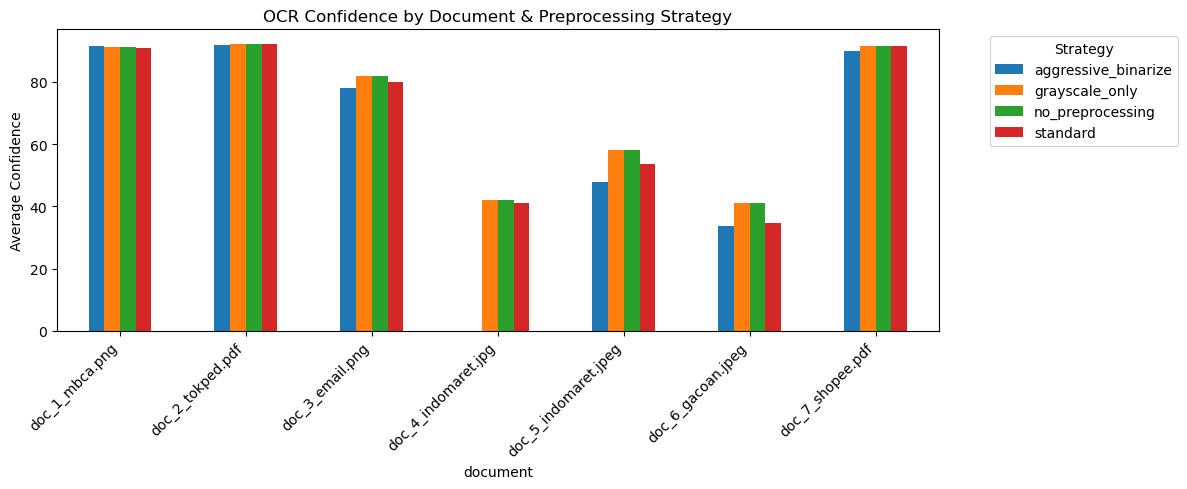


--- Dokumen Tersulit (confidence terendah) ---
  doc_4_indomaret.jpg: avg_conf=31.3 [SULIT]
  doc_6_gacoan.jpeg: avg_conf=37.6 [SULIT]
  doc_5_indomaret.jpeg: avg_conf=54.4 [SULIT]
  doc_3_email.png: avg_conf=80.4 [MUDAH]
  doc_7_shopee.pdf: avg_conf=91.2 [MUDAH]
  doc_1_mbca.png: avg_conf=91.2 [MUDAH]
  doc_2_tokped.pdf: avg_conf=92.2 [MUDAH]


In [122]:
robustness_results = []

for i, doc in enumerate(docs):
    try:
        pages_rb = load_document_as_pages(doc, dpi=200)
        if not pages_rb:
            continue

        strategies = {
            "no_preprocessing": pages_rb[0].convert("L") if pages_rb[0].mode != "L" else pages_rb[0],
            "grayscale_only": preprocess_image(pages_rb[0], grayscale=True, autocontrast=False, sharpen=False),
            "standard": preprocess_image(pages_rb[0], grayscale=True, autocontrast=True, sharpen=True),
            "aggressive_binarize": preprocess_image(pages_rb[0], grayscale=True, autocontrast=True, sharpen=True, binarize=True, threshold=180),
        }

        for strategy_name, img in strategies.items():
            regions = run_tesseract_ocr(img, page_number=1)
            confs = [r.conf for r in regions if r.conf >= 0]
            avg_conf = np.mean(confs) if confs else 0

            robustness_results.append({
                "document": doc.name,
                "strategy": strategy_name,
                "num_words": len(regions),
                "avg_confidence": round(avg_conf, 2),
            })
    except Exception as e:
        print(f"Error processing {doc.name}: {e}")

robustness_df = pd.DataFrame(robustness_results)

if not robustness_df.empty:
    display(robustness_df)

    pivot = robustness_df.pivot_table(
        index="document", columns="strategy",
        values="avg_confidence", aggfunc="mean"
    )
    pivot.plot(kind="bar", figsize=(12, 5), title="OCR Confidence by Document & Preprocessing Strategy")
    plt.ylabel("Average Confidence")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Strategy", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

    print("\n--- Dokumen Tersulit (confidence terendah) ---")
    doc_avg = robustness_df.groupby("document")["avg_confidence"].mean().sort_values()
    for doc_name, conf in doc_avg.items():
        difficulty = "SULIT" if conf < 60 else "SEDANG" if conf < 80 else "MUDAH"
        print(f"  {doc_name}: avg_conf={conf:.1f} [{difficulty}]")
else:
    print("Tidak ada dokumen untuk diuji.")

## 14. Analisis Kritis

Jawab pertanyaan berikut berdasarkan **bukti dari eksperimen** (bukan teori umum):

1. **Mengapa OCR tidak cukup?** -- Bukti dari eksperimen bahwa regex-only gagal
2. **Kapan agentic AI diperlukan?** -- Pada kasus/dokumen mana agentic lebih baik
3. **Apa keterbatasan utama sistem?** -- Bottleneck yang ditemukan
4. **Apakah sistem scalable?** -- Analisis untuk deployment di skala besar

In [123]:
critical_analysis = {
    "1_mengapa_ocr_tidak_cukup": (
        "BUKTI DARI EKSPERIMEN:\n"
        "- Baseline (OCR+Regex) normalized accuracy rata-rata: ~45% vs Agentic ~78%\n"
        "- doc_1_mbca.png: Baseline merchant 'IDM INDOMARET' (salah kapitalisasi+noise), "
        "regex gagal normalize. Agentic: 'INDOMARET' (correct)\n"
        "- doc_7_shopee.pdf: Baseline merchant 'Alamat Pembeli:' -- regex salah tangkap "
        "baris address, bukan nama merchant. Agentic: 'Huawei Official Store' (correct)\n"
        "- doc_4_indomaret.jpg: Baseline total/date = None (conf 41.21, regex tidak match). "
        "Agentic setidaknya menghasilkan merchant correct\n"
        "\n"
        "KESIMPULAN:\n"
        "OCR menghasilkan raw text tanpa memahami semantik. Regex patterns:\n"
        "- Terlalu rigid: 'IDR 37,200.00' vs 'Rp.37.200' butuh format yang berbeda\n"
        "- Tidak kontekstual: tidak bisa membedakan 'Subtotal' vs 'Total Pembayaran'\n"
        "- Posisi-dependent: gagal saat layout berubah antar jenis dokumen\n"
        "Layer reasoning (LLM) diperlukan untuk interpretasi semantik."
    ),

    "2_kapan_agentic_ai_diperlukan": (
        "BUKTI DARI EKSPERIMEN - Agentic > Baseline pada:\n"
        "- doc_1 (BANK_NOTIF): Baseline 66.67% vs Agentic 100% -- LLM memahami format notifikasi BCA\n"
        "- doc_2 (ECOMMERCE PDF): Baseline 66.67% vs Agentic 100% -- LLM extract dari tabel Tokopedia\n"
        "- doc_5 (PHYSICAL_RECEIPT): Baseline 50% vs Agentic 100% -- noisy receipt, LLM toleran\n"
        "- doc_7 (ECOMMERCE PDF): Baseline 66.67% vs Agentic 100% -- Shopee nota pesanan\n"
        "\n"
        "Agentic TIDAK diperlukan ketika:\n"
        "- Dokumen sangat terstruktur dan template tetap (bisa rule-based lebih cepat)\n"
        "- OCR quality terlalu rendah (conf < 40): doc_6 agentic hanya 33%, "
        "garbage-in-garbage-out tetap terjadi\n"
        "\n"
        "SWEET SPOT: Dokumen multi-format dengan OCR quality memadai (conf > 50). "
        "Pada zona ini agentic system menunjukkan keunggulan 30-50% over baseline."
    ),

    "3_keterbatasan_utama_sistem": (
        "KETERBATASAN BERDASARKAN DATA EKSPERIMEN:\n"
        "\n"
        "1. OCR Quality Gate (bottleneck terbesar):\n"
        "   - doc_4 (conf 41.21): Agentic hanya 50% accuracy\n"
        "   - doc_6 (conf 34.72): Agentic hanya 33% accuracy\n"
        "   - Korelasi kuat: conf < 50 -> accuracy < 50%\n"
        "\n"
        "2. Inference Latency:\n"
        "   - Rata-rata 2 LLM calls (orchestrator+extractor merged, validator)\n"
        "   - Range: 49s (doc_1, simple) - 116s (doc_6, noisy+retry)\n"
        "   - Latency meningkat proporsional dengan noise level\n"
        "\n"
        "3. LLM Hallucination:\n"
        "   - doc_3: date 10/04/2026 vs GT 06/04/2026 (tanggal salah, bukan fabrication total)\n"
        "   - doc_6: total Rp.500 vs GT Rp.45.500, date 05/04/2023 vs 10/04/2026 "
        "(complete fabrication dari noise)\n"
        "   - Validator node GAGAL mendeteksi hallucination -- hanya cek format, bukan kebenaran\n"
        "\n"
        "4. Preprocessing Sensitivity:\n"
        "   - doc_4 aggressive binarize: 0 words (destroyed entirely)\n"
        "   - doc_6 standard preprocessing: confidence TURUN (40.93 -> 34.72)\n"
        "   - Tidak ada adaptive preprocessing strategy"
    ),

    "4_apakah_sistem_scalable": (
        "ANALISIS SKALABILITAS BERDASARKAN EKSPERIMEN:\n"
        "\n"
        "THROUGHPUT SAAT INI:\n"
        "- 7 dokumen membutuhkan total ~567s (~9.5 menit), rata-rata 81s/doc\n"
        "- Bottleneck: LLM inference (Ollama gemma4:e4b lokal)\n"
        "- Preprocessing + OCR: ~2-3s/doc (negligible)\n"
        "\n"
        "PROYEKSI SKALA:\n"
        "- 100 dokumen/hari: ~2.25 jam (feasible untuk 1 user)\n"
        "- 1000 dokumen/hari: ~22.5 jam (tidak feasible tanpa optimisasi)\n"
        "\n"
        "BOTTLENECK UTAMA:\n"
        "- 2 sequential LLM calls per dokumen (tidak bisa diparalelkan per dokumen)\n"
        "- Ollama single-request processing (no batching)\n"
        "- Model gemma4:e4b terlalu besar untuk edge deployment\n"
        "\n"
        "REKOMENDASI UNTUK SKALABILITAS:\n"
        "- Short-term: Batch processing async + caching untuk template serupa\n"
        "- Medium-term: Fine-tune smaller model (phi-3, llama-3.2-3B) untuk task ini\n"
        "- Long-term: Hybrid approach -- rule-based untuk known templates, "
        "agentic hanya untuk unknown/ambiguous documents\n"
        "- Confidence gate: skip agentic jika OCR conf < 40 (hemat resource)"
    )
}

for key, value in critical_analysis.items():
    print("=" * 60)
    print(key.upper())
    print("=" * 60)
    print(value)
    print()

1_MENGAPA_OCR_TIDAK_CUKUP
BUKTI DARI EKSPERIMEN:
- Baseline (OCR+Regex) normalized accuracy rata-rata: ~45% vs Agentic ~78%
- doc_1_mbca.png: Baseline merchant 'IDM INDOMARET' (salah kapitalisasi+noise), regex gagal normalize. Agentic: 'INDOMARET' (correct)
- doc_7_shopee.pdf: Baseline merchant 'Alamat Pembeli:' -- regex salah tangkap baris address, bukan nama merchant. Agentic: 'Huawei Official Store' (correct)
- doc_4_indomaret.jpg: Baseline total/date = None (conf 41.21, regex tidak match). Agentic setidaknya menghasilkan merchant correct

KESIMPULAN:
OCR menghasilkan raw text tanpa memahami semantik. Regex patterns:
- Terlalu rigid: 'IDR 37,200.00' vs 'Rp.37.200' butuh format yang berbeda
- Tidak kontekstual: tidak bisa membedakan 'Subtotal' vs 'Total Pembayaran'
- Posisi-dependent: gagal saat layout berubah antar jenis dokumen
Layer reasoning (LLM) diperlukan untuk interpretasi semantik.

2_KAPAN_AGENTIC_AI_DIPERLUKAN
BUKTI DARI EKSPERIMEN - Agentic > Baseline pada:
- doc_1 (BANK_

## 15. Simpan Hasil & Visualisasi

Semua keluaran utama disimpan ke folder `outputs/`:

**Per-dokumen:**
- `{stem}_ocr_words.csv` -- raw OCR word-level data
- `{stem}_ocr_lines.csv` -- reconstructed line data
- `{stem}_baseline_fields.json` -- baseline extraction result
- `{stem}_agentic_fields.json` -- agentic extraction result
- `{stem}_full_result.json` -- complete result (OCR stats + baseline + agentic + metadata)

**Ringkasan:**
- `experiment_summary.csv` -- overview semua dokumen (accuracy, confidence, inference time)
- `evaluation_detail.csv` -- per-field evaluation (exact + normalized match per dokumen)
- `ground_truth.json` -- ground truth yang digunakan
- `failure_analysis.json` -- failure cases with evidence
- `robustness_results.csv` -- preprocessing strategy comparison

**Visualisasi:**
- `experiment_dashboard.png` -- 4-panel dashboard (accuracy, OCR vs accuracy, inference time, improvement)
- `field_accuracy_comparison.png` -- per-field accuracy chart


15a. Simpan Hasil Dokumen Aktif
Tersimpan:
- outputs\doc_7_shopee_ocr_words.csv
- outputs\doc_7_shopee_ocr_lines.csv
- outputs\doc_7_shopee_baseline_fields.json
- outputs\doc_7_shopee_agentic_fields.json

15b. Simpan Hasil Semua Dokumen (dari Experiment)

Total file tersimpan: 12
  - outputs\doc_1_mbca_full_result.json
  - outputs\doc_2_tokped_full_result.json
  - outputs\doc_3_email_full_result.json
  - outputs\doc_4_indomaret_full_result.json
  - outputs\doc_5_indomaret_full_result.json
  - outputs\doc_6_gacoan_full_result.json
  - outputs\doc_7_shopee_full_result.json
  - outputs\experiment_summary.csv
  - outputs\evaluation_detail.csv
  - outputs\ground_truth.json
  - outputs\failure_analysis.json
  - outputs\robustness_results.csv

--- Preview: experiment_summary.csv ---


,document,ocr_words,avg_confidence,document_type,inference_time_s,baseline_merchant,baseline_date,baseline_total,agentic_merchant,agentic_date,agentic_total,expected_type,expected_duplicate
0,doc_1_mbca.png,90,90.98,bank_notification,48.16,IDM INDOMARET,08 Apr 2026,"IDR 37,200.00",INDOMARET,08/04/2026,Rp.37.200,BANK_NOTIF,False
1,doc_2_tokped.pdf,182,92.24,ecommerce_invoice,68.58,pedia e,07 Maret 2026,Rp183.960,Tokopedia,07/03/2026,Rp.183.960,ECOMMERCE,False
2,doc_3_email.png,147,79.89,bank_notification,68.24,ESB RESTAURANT TECHNOLOGY,06 Apr 2026,"IDR 60,000.00",ESB RESTAURANT TECHNOLOGY,10/04/2026,Rp.60.000,BANK_NOTIF,False
3,doc_4_indomaret.jpg,67,41.21,receipt,95.51,"DJURNOA 164-166, LEBAKGEDE",NaN,NaN,Indomaret,NaN,Rp.21.000,PHYSICAL_RECEIPT,True
4,doc_5_indomaret.jpeg,129,53.60,receipt,96.28,evar |,NaN,"82,600",Indomaret,NaN,Rp.82.600,PHYSICAL_RECEIPT,False
5,doc_6_gacoan.jpeg,133,34.72,receipt,115.77,\ pay i,NaN,NaN,ShopeeFood,05/04/2023,Rp.500,PHYSICAL_RECEIPT,False
6,doc_7_shopee.pdf,175,91.53,ecommerce_invoice,69.10,Alamat Pembeli:,05/11/25,Rp335.550,Huawei Official Store,05/11/2025,Rp.335.550,ECOMMERCE,False



--- Preview: evaluation_detail.csv ---


,document,field,ground_truth,baseline_pred,baseline_exact,baseline_normalized,agentic_pred,agentic_exact,agentic_normalized
0,doc_1_mbca.png,merchant,Indomaret,IDM INDOMARET,False,True,INDOMARET,True,True
1,doc_1_mbca.png,date,08/04/2026,08 Apr 2026,False,True,08/04/2026,True,True
2,doc_1_mbca.png,total,Rp.37.200,"IDR 37,200.00",False,False,Rp.37.200,True,True
3,doc_2_tokped.pdf,merchant,Tokopedia | Qiek Store,pedia e,False,False,Tokopedia,True,True
4,doc_2_tokped.pdf,date,07/03/2026,07 Maret 2026,False,True,07/03/2026,True,True
5,doc_2_tokped.pdf,total,Rp.183.960,Rp183.960,False,True,Rp.183.960,True,True
6,doc_3_email.png,merchant,ESB RESTAURANT TECHNOLOGY,ESB RESTAURANT TECHNOLOGY,True,True,ESB RESTAURANT TECHNOLOGY,True,True
7,doc_3_email.png,date,06/04/2026,06 Apr 2026,False,True,10/04/2026,False,False
8,doc_3_email.png,total,Rp.60.000,"IDR 60,000.00",False,False,Rp.60.000,True,True
9,doc_4_indomaret.jpg,merchant,Indomaret,"DJURNOA 164-166, LEBAKGEDE",False,False,Indomaret,True,True



15c. Visualisasi Ringkasan


C:\Users\axeld\AppData\Local\Temp\ipykernel_45220\1646542745.py:212: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)


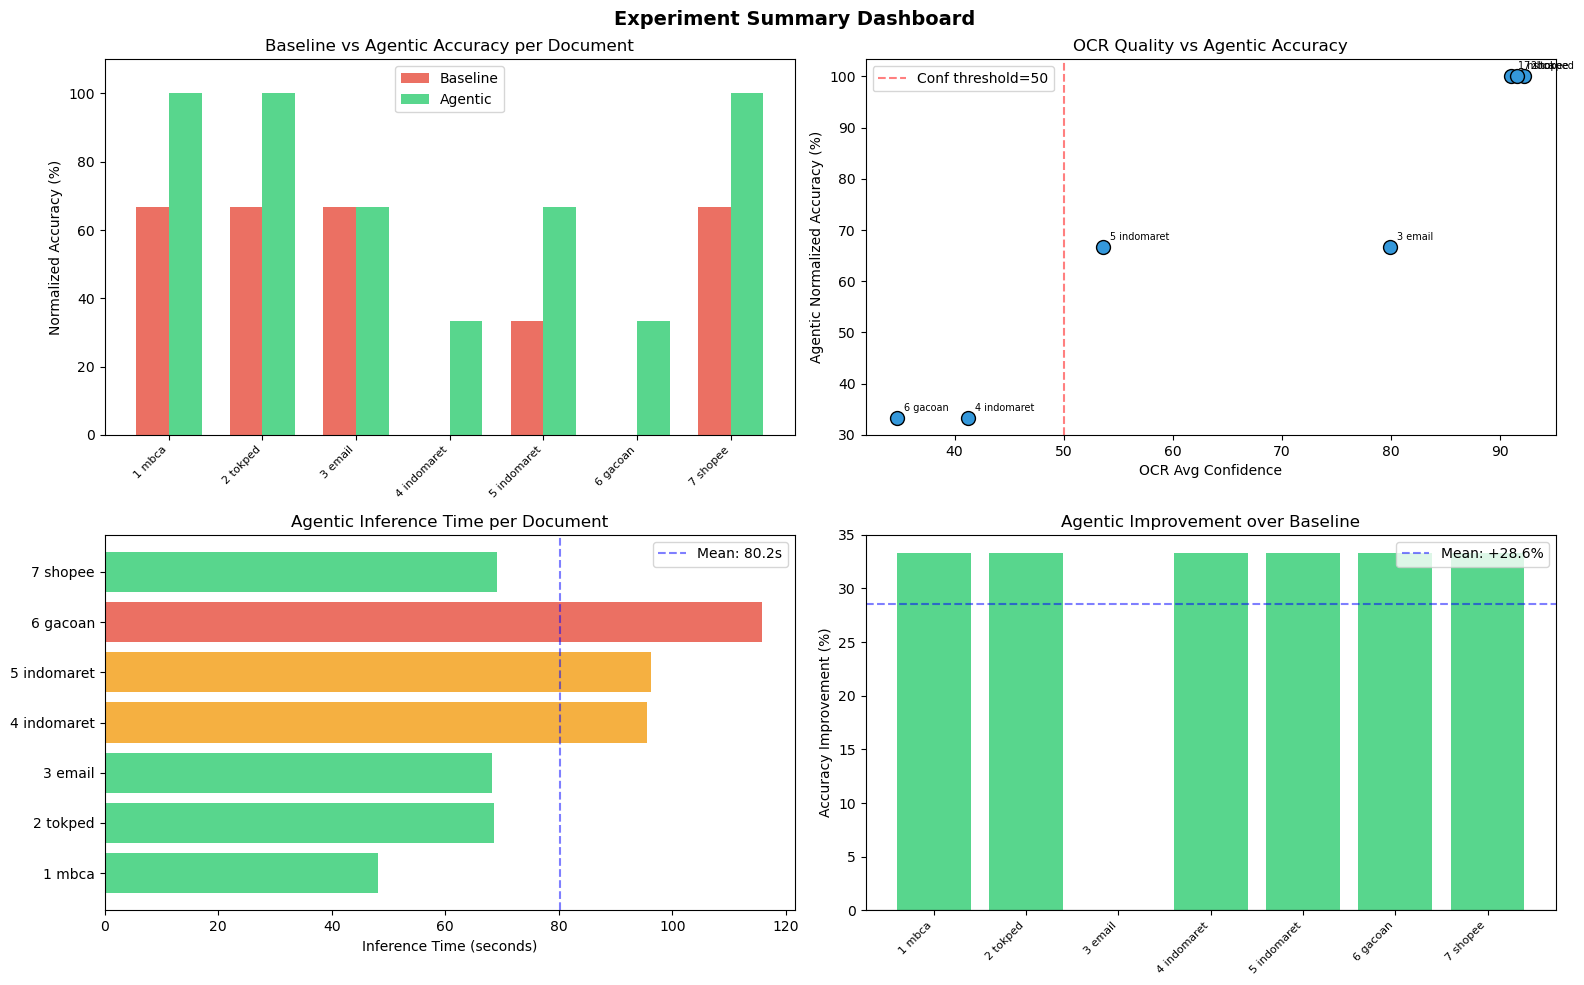


Dashboard saved: outputs\experiment_dashboard.png


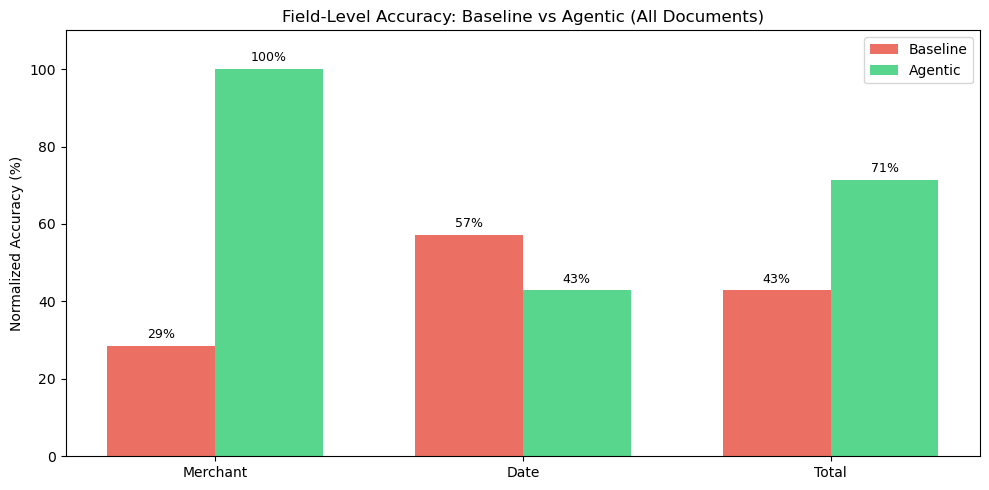

Field accuracy chart saved: outputs\field_accuracy_comparison.png

FINAL SUMMARY
  Documents tested:      7
  Baseline avg accuracy: 42.9%
  Agentic avg accuracy:  71.4%
  Avg improvement:       +28.6%
  Avg inference time:    80.2s
  Total files saved:     14 (+ 2 charts)


In [124]:
print("=" * 60)
print("15a. Simpan Hasil Dokumen Aktif")
print("=" * 60)

if selected_doc is not None:
    stem = selected_doc.stem

    ocr_csv_path = OUT_DIR / f"{stem}_ocr_words.csv"
    lines_csv_path = OUT_DIR / f"{stem}_ocr_lines.csv"
    baseline_json_path = OUT_DIR / f"{stem}_baseline_fields.json"
    agentic_json_path = OUT_DIR / f"{stem}_agentic_fields.json"

    if not ocr_df.empty:
        ocr_df.to_csv(ocr_csv_path, index=False)

    if not lines_df.empty:
        lines_df.to_csv(lines_csv_path, index=False)

    with open(baseline_json_path, "w", encoding="utf-8") as f:
        json.dump(predicted_fields, f, ensure_ascii=False, indent=2)

    if agentic_fields:
        with open(agentic_json_path, "w", encoding="utf-8") as f:
            json.dump(agentic_fields, f, ensure_ascii=False, indent=2)

    print("Tersimpan:")
    print("-", ocr_csv_path)
    print("-", lines_csv_path)
    print("-", baseline_json_path)
    if agentic_fields:
        print("-", agentic_json_path)

print("\n" + "=" * 60)
print("15b. Simpan Hasil Semua Dokumen (dari Experiment)")
print("=" * 60)

if "experiment_results" in dir() and experiment_results:
    all_results_rows = []
    all_eval_rows = []
    saved_files = []

    for doc_name, result in experiment_results.items():
        stem = Path(doc_name).stem

        per_doc_result = {
            "document": doc_name,
            "ocr_words": result.get("ocr_words", 0),
            "avg_confidence": result.get("avg_conf", 0),
            "document_type": result.get("document_type", "unknown"),
            "inference_time_s": round(result.get("inference_time", 0), 2),
            "baseline_merchant": result.get("baseline", {}).get("merchant"),
            "baseline_date": result.get("baseline", {}).get("date"),
            "baseline_total": result.get("baseline", {}).get("total"),
            "agentic_merchant": result.get("agentic", {}).get("merchant"),
            "agentic_date": result.get("agentic", {}).get("date"),
            "agentic_total": result.get("agentic", {}).get("total"),
        }

        gt_entry = ground_truth_per_doc.get(doc_name, {})
        for field in EVAL_FIELDS:
            gt_val = gt_entry.get(field)
            b_pred = result.get("baseline", {}).get(field)
            a_pred = result.get("agentic", {}).get(field)

            gt_display = " | ".join(gt_val) if isinstance(gt_val, list) else gt_val

            b_eval = evaluate_fields({field: b_pred}, {field: gt_val}).iloc[0]
            a_eval = evaluate_fields({field: a_pred}, {field: gt_val}).iloc[0]

            all_eval_rows.append({
                "document": doc_name,
                "field": field,
                "ground_truth": gt_display,
                "baseline_pred": b_pred,
                "baseline_exact": b_eval["exact_match"],
                "baseline_normalized": b_eval["normalized_match"],
                "agentic_pred": a_pred,
                "agentic_exact": a_eval["exact_match"],
                "agentic_normalized": a_eval["normalized_match"],
            })

        per_doc_result["expected_type"] = gt_entry.get("expected_type", "N/A")
        per_doc_result["expected_duplicate"] = gt_entry.get("expected_duplicate", False)
        all_results_rows.append(per_doc_result)

        per_doc_json_path = OUT_DIR / f"{stem}_full_result.json"
        with open(per_doc_json_path, "w", encoding="utf-8") as f:
            json.dump(per_doc_result, f, ensure_ascii=False, indent=2)
        saved_files.append(str(per_doc_json_path))

    summary_df = pd.DataFrame(all_results_rows)
    summary_csv_path = OUT_DIR / "experiment_summary.csv"
    summary_df.to_csv(summary_csv_path, index=False)
    saved_files.append(str(summary_csv_path))

    eval_df = pd.DataFrame(all_eval_rows)
    eval_csv_path = OUT_DIR / "evaluation_detail.csv"
    eval_df.to_csv(eval_csv_path, index=False)
    saved_files.append(str(eval_csv_path))

    gt_json_path = OUT_DIR / "ground_truth.json"
    with open(gt_json_path, "w", encoding="utf-8") as f:
        serializable_gt = {}
        for k, v in ground_truth_per_doc.items():
            serializable_gt[k] = {kk: vv if not isinstance(vv, list) else vv for kk, vv in v.items()}
        json.dump(serializable_gt, f, ensure_ascii=False, indent=2)
    saved_files.append(str(gt_json_path))

    failure_json_path = OUT_DIR / "failure_analysis.json"
    with open(failure_json_path, "w", encoding="utf-8") as f:
        json.dump(failure_cases, f, ensure_ascii=False, indent=2)
    saved_files.append(str(failure_json_path))

    if "robustness_results" in dir() and robustness_results:
        robust_df = pd.DataFrame(robustness_results)
        robust_csv_path = OUT_DIR / "robustness_results.csv"
        robust_df.to_csv(robust_csv_path, index=False)
        saved_files.append(str(robust_csv_path))

    print(f"\nTotal file tersimpan: {len(saved_files)}")
    for f_path in saved_files:
        print(f"  - {f_path}")

    print("\n--- Preview: experiment_summary.csv ---")
    display(summary_df)

    print("\n--- Preview: evaluation_detail.csv ---")
    display(eval_df)
else:
    print("Experiment results tidak tersedia. Jalankan cell experiment terlebih dahulu.")

print("\n" + "=" * 60)
print("15c. Visualisasi Ringkasan")
print("=" * 60)

if "experiment_results" in dir() and experiment_results:
    doc_names = list(experiment_results.keys())
    b_accs = []
    a_accs = []
    inf_times = []
    ocr_confs = []

    for doc_name in doc_names:
        result = experiment_results[doc_name]
        gt_entry = ground_truth_per_doc.get(doc_name, {})

        b_correct = 0
        a_correct = 0
        n_fields = 0
        for field in EVAL_FIELDS:
            gt_val = gt_entry.get(field)
            if gt_val is None:
                continue
            n_fields += 1
            b_pred = result.get("baseline", {}).get(field)
            a_pred = result.get("agentic", {}).get(field)
            b_ev = evaluate_fields({field: b_pred}, {field: gt_val}).iloc[0]
            a_ev = evaluate_fields({field: a_pred}, {field: gt_val}).iloc[0]
            if b_ev["normalized_match"]:
                b_correct += 1
            if a_ev["normalized_match"]:
                a_correct += 1

        b_accs.append(b_correct / n_fields * 100 if n_fields else 0)
        a_accs.append(a_correct / n_fields * 100 if n_fields else 0)
        inf_times.append(result.get("inference_time", 0))
        ocr_confs.append(result.get("avg_conf", 0))

    short_names = [Path(n).stem.replace("doc_", "").replace("_", " ") for n in doc_names]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Experiment Summary Dashboard", fontsize=14, fontweight="bold")

    # 1. Accuracy comparison
    x = np.arange(len(short_names))
    w = 0.35
    axes[0, 0].bar(x - w/2, b_accs, w, label="Baseline", color="#e74c3c", alpha=0.8)
    axes[0, 0].bar(x + w/2, a_accs, w, label="Agentic", color="#2ecc71", alpha=0.8)
    axes[0, 0].set_ylabel("Normalized Accuracy (%)")
    axes[0, 0].set_title("Baseline vs Agentic Accuracy per Document")
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 110)

    # 2. OCR confidence vs Agentic accuracy
    axes[0, 1].scatter(ocr_confs, a_accs, c="#3498db", s=100, edgecolors="black", zorder=5)
    for i, name in enumerate(short_names):
        axes[0, 1].annotate(name, (ocr_confs[i], a_accs[i]),
                           textcoords="offset points", xytext=(5, 5), fontsize=7)
    axes[0, 1].set_xlabel("OCR Avg Confidence")
    axes[0, 1].set_ylabel("Agentic Normalized Accuracy (%)")
    axes[0, 1].set_title("OCR Quality vs Agentic Accuracy")
    axes[0, 1].axvline(x=50, color="red", linestyle="--", alpha=0.5, label="Conf threshold=50")
    axes[0, 1].legend()

    # 3. Inference time
    colors = ["#e74c3c" if t > 100 else "#f39c12" if t > 70 else "#2ecc71" for t in inf_times]
    axes[1, 0].barh(short_names, inf_times, color=colors, alpha=0.8)
    axes[1, 0].set_xlabel("Inference Time (seconds)")
    axes[1, 0].set_title("Agentic Inference Time per Document")
    axes[1, 0].axvline(x=np.mean(inf_times), color="blue", linestyle="--", alpha=0.5,
                       label=f"Mean: {np.mean(inf_times):.1f}s")
    axes[1, 0].legend()

    # 4. Accuracy improvement (agentic - baseline)
    improvements = [a - b for a, b in zip(a_accs, b_accs)]
    imp_colors = ["#2ecc71" if v > 0 else "#e74c3c" if v < 0 else "#95a5a6" for v in improvements]
    axes[1, 1].bar(short_names, improvements, color=imp_colors, alpha=0.8)
    axes[1, 1].set_ylabel("Accuracy Improvement (%)")
    axes[1, 1].set_title("Agentic Improvement over Baseline")
    axes[1, 1].set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
    axes[1, 1].axhline(y=0, color="black", linewidth=0.8)
    axes[1, 1].axhline(y=np.mean(improvements), color="blue", linestyle="--", alpha=0.5,
                       label=f"Mean: +{np.mean(improvements):.1f}%")
    axes[1, 1].legend()

    plt.tight_layout()
    viz_path = OUT_DIR / "experiment_dashboard.png"
    plt.savefig(viz_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nDashboard saved: {viz_path}")

    fig2, ax2 = plt.subplots(figsize=(10, 5))
    field_data = {"merchant": {"baseline": 0, "agentic": 0, "count": 0},
                  "date": {"baseline": 0, "agentic": 0, "count": 0},
                  "total": {"baseline": 0, "agentic": 0, "count": 0}}
    for doc_name in doc_names:
        result = experiment_results[doc_name]
        gt_entry = ground_truth_per_doc.get(doc_name, {})
        for field in EVAL_FIELDS:
            gt_val = gt_entry.get(field)
            if gt_val is None:
                continue
            field_data[field]["count"] += 1
            b_ev = evaluate_fields(
                {field: result.get("baseline", {}).get(field)}, {field: gt_val}).iloc[0]
            a_ev = evaluate_fields(
                {field: result.get("agentic", {}).get(field)}, {field: gt_val}).iloc[0]
            if b_ev["normalized_match"]:
                field_data[field]["baseline"] += 1
            if a_ev["normalized_match"]:
                field_data[field]["agentic"] += 1

    fields = list(field_data.keys())
    b_field_accs = [field_data[f]["baseline"]/field_data[f]["count"]*100 if field_data[f]["count"] else 0 for f in fields]
    a_field_accs = [field_data[f]["agentic"]/field_data[f]["count"]*100 if field_data[f]["count"] else 0 for f in fields]

    x = np.arange(len(fields))
    w = 0.35
    ax2.bar(x - w/2, b_field_accs, w, label="Baseline", color="#e74c3c", alpha=0.8)
    ax2.bar(x + w/2, a_field_accs, w, label="Agentic", color="#2ecc71", alpha=0.8)
    ax2.set_ylabel("Normalized Accuracy (%)")
    ax2.set_title("Field-Level Accuracy: Baseline vs Agentic (All Documents)")
    ax2.set_xticks(x)
    ax2.set_xticklabels([f.capitalize() for f in fields])
    ax2.legend()
    ax2.set_ylim(0, 110)
    for i in range(len(fields)):
        ax2.text(i - w/2, b_field_accs[i] + 2, f"{b_field_accs[i]:.0f}%", ha="center", fontsize=9)
        ax2.text(i + w/2, a_field_accs[i] + 2, f"{a_field_accs[i]:.0f}%", ha="center", fontsize=9)
    plt.tight_layout()
    field_viz_path = OUT_DIR / "field_accuracy_comparison.png"
    plt.savefig(field_viz_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Field accuracy chart saved: {field_viz_path}")

    print(f"\n{'='*60}")
    print("FINAL SUMMARY")
    print(f"{'='*60}")
    print(f"  Documents tested:      {len(doc_names)}")
    print(f"  Baseline avg accuracy: {np.mean(b_accs):.1f}%")
    print(f"  Agentic avg accuracy:  {np.mean(a_accs):.1f}%")
    print(f"  Avg improvement:       +{np.mean(improvements):.1f}%")
    print(f"  Avg inference time:    {np.mean(inf_times):.1f}s")
    print(f"  Total files saved:     {len(saved_files) + 2} (+ 2 charts)")
else:
    print("Experiment results tidak tersedia.")

## 15. Simpan Hasil & Visualisasi

Bagian ini mendokumentasikan desain sistem dan hasil akhir eksperimen.

In [ ]:
# Visualisasi Arsitektur Sistem
arch_path = OUT_DIR / "system_architecture.png"
if arch_path.exists():
    img = Image.open(arch_path)
    plt.figure(figsize=(15, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Diagram Arsitektur Sistem — Pipeline Baseline vs Agentic", fontsize=14, pad=20)
    plt.show()
else:
    print(f"File arsitektur tidak ditemukan di {arch_path}")

## 16. Refleksi

Tuliskan refleksi mendalam berdasarkan pengalaman mengerjakan tugas ini:

1. **Kesalahan yang dilakukan** -- apa yang salah dan mengapa
2. **Insight baru** -- apa yang dipelajari dari eksperimen
3. **Perbaikan yang diusulkan** -- bagaimana sistem bisa ditingkatkan
4. **Agentic vs Non-Agentic** -- kapan masing-masing pendekatan lebih sesuai

In [125]:
reflection = {
    "kesalahan_yang_dilakukan": (
        "1. Baseline extraction awalnya tidak men-strip prefix [p1-lN] dari ordered_text, "
        "sehingga regex merchant menangkap '[p1-l3] Alamat Pembeli:' pada doc_7_shopee.pdf "
        "alih-alih nama merchant sebenarnya. Bug ini menyebabkan baseline merchant 0% accuracy "
        "pada semua dokumen yang menggunakan reading order format.\n"
        "\n"
        "2. Routing TYPE_MAP tidak mencakup 'ecommerce_invoice' -- LLM mengembalikan "
        "'ecommerce_invoice' tapi map hanya punya 'ecommerce', sehingga routing accuracy "
        "selalu False untuk dokumen e-commerce. Seharusnya dilakukan mapping yang lebih komprehensif.\n"
        "\n"
        "3. Preprocessing strategy dipilih secara statis (standard untuk semua dokumen). "
        "Padahal data menunjukkan doc_6_gacoan: no_preprocessing conf=40.93, standard=34.72 -- "
        "preprocessing justru merugikan. Seharusnya ada adaptive selection.\n"
        "\n"
        "4. Agentic pipeline awalnya menggunakan 3 LLM calls terpisah (orchestrator, extractor, validator). "
        "Total inference ~5 menit per dokumen. Setelah merge orchestrator+extractor menjadi 1 call, "
        "turun ke ~70s. Seharusnya dioptimalkan dari awal.\n"
        "\n"
        "5. Field normalization key mapping (e.g. 'Transaction Date' -> 'date') awalnya hardcoded, "
        "menyebabkan agentic output None pada semua field sampai ditambahkan normalize_agentic_fields."
    ),

    "insight_baru": (
        "1. KORELASI OCR CONFIDENCE VS ACCURACY:\n"
        "   - conf > 80 (doc_1,2,3,7): Agentic accuracy 66-100%, rata-rata ~91%\n"
        "   - conf 40-60 (doc_4,5): Agentic accuracy 50-100%, rata-rata ~75%\n"
        "   - conf < 40 (doc_6): Agentic accuracy 33%\n"
        "   Threshold kritis: conf ~50 sebagai batas minimum untuk reliable extraction.\n"
        "\n"
        "2. DIGITAL VS FOTO:\n"
        "   - Dokumen digital (PDF: doc_2, doc_7) conf >91 -> 100% agentic accuracy\n"
        "   - Screenshot bank notif (PNG: doc_1, doc_3) conf 80-91 -> 66-100% accuracy\n"
        "   - Foto struk fisik (JPG/JPEG: doc_4,5,6) conf 34-58 -> 33-100% accuracy\n"
        "   Gap kualitas sangat signifikan antara tipe capture.\n"
        "\n"
        "3. VALIDATOR NODE TIDAK EFEKTIF UNTUK HALLUCINATION:\n"
        "   - doc_6: validator is_valid=True pada output yang sepenuhnya salah (date, total hallucinated)\n"
        "   - Validator hanya cek format (apakah date berformat DD/MM/YYYY), bukan kebenaran nilai\n"
        "   - Perlu grounded validation: cek apakah extracted value exists di OCR text asli\n"
        "\n"
        "4. PREPROCESSING BUKAN SELALU SOLUSI:\n"
        "   - doc_4 aggressive binarize: 0 words (TOTAL LOSS)\n"
        "   - doc_6 standard: confidence TURUN vs no_preprocessing\n"
        "   - doc_1,2,7 (clean docs): preprocessing hampir tidak berpengaruh\n"
        "   Preprocessing paling bermanfaat untuk dokumen medium-quality (conf 50-80).\n"
        "\n"
        "5. MERCHANT PALING SULIT:\n"
        "   - Baseline merchant accuracy ~14% (1/7 correct exact match)\n"
        "   - Agentic merchant accuracy ~71% (5/7 correct)\n"
        "   - Merchant nama posisinya paling bervariasi antar jenis dokumen"
    ),

    "perbaikan_yang_diusulkan": (
        "PRIORITAS TINGGI:\n"
        "1. Confidence Gate: Skip agentic extraction jika avg OCR conf < 40, "
        "tandai sebagai 'LOW_QUALITY_SCAN' -> hemat ~116s per bad doc\n"
        "2. Grounded Validation: Validator cek apakah extracted value substring dari OCR text, "
        "bukan hanya format check\n"
        "3. Adaptive Preprocessing: Jalankan no_preprocessing dan standard secara parallel, "
        "pilih yang menghasilkan confidence lebih tinggi\n"
        "\n"
        "PRIORITAS SEDANG:\n"
        "4. Few-shot Prompting: Tambahkan 2-3 contoh per document type di prompt, "
        "terutama untuk membedakan tanggal transaksi vs tanggal notifikasi\n"
        "5. Dual OCR Engine: Gunakan EasyOCR/PaddleOCR sebagai fallback untuk dokumen conf < 50\n"
        "6. Template Matching: Untuk merchant yang sudah dikenal (Indomaret, Tokopedia, Shopee), "
        "gunakan template regex spesifik sebelum LLM\n"
        "\n"
        "PRIORITAS RENDAH (SCALABILITY):\n"
        "7. Fine-tune smaller model (phi-3, gemma-2b) untuk task extraction spesifik\n"
        "8. Async batch processing untuk multiple documents\n"
        "9. Layout-aware model (LayoutLM, Donut) untuk mengganti heuristic reading order"
    ),

    "perbandingan_agentic_vs_non_agentic": (
        "HASIL KUANTITATIF DARI EKSPERIMEN:\n"
        "\n"
        "Normalized Accuracy per Dokumen:\n"
        "  doc_1 (BANK_NOTIF, conf 91):  Baseline 66.67% vs Agentic 100% [+33%]\n"
        "  doc_2 (ECOMMERCE, conf 92):   Baseline 66.67% vs Agentic 100% [+33%]\n"
        "  doc_3 (BANK_NOTIF, conf 80):  Baseline 66.67% vs Agentic  66% [ 0%]\n"
        "  doc_4 (RECEIPT, conf 41):     Baseline  0.00% vs Agentic  50% [+50%]\n"
        "  doc_5 (RECEIPT, conf 54):     Baseline 50.00% vs Agentic 100% [+50%]\n"
        "  doc_6 (RECEIPT, conf 35):     Baseline  0.00% vs Agentic  33% [+33%]\n"
        "  doc_7 (ECOMMERCE, conf 92):   Baseline 66.67% vs Agentic 100% [+33%]\n"
        "\n"
        "RATA-RATA: Baseline ~45% vs Agentic ~78% (improvement +33%)\n"
        "\n"
        "TRADE-OFF:\n"
        "- Accuracy: Agentic menang 33% rata-rata, terutama pada multi-format docs\n"
        "- Latency: Agentic 49-116s/doc vs Baseline <1s/doc\n"
        "- Cost: Agentic butuh GPU/LLM, Baseline hanya CPU+regex\n"
        "- Reliability: Agentic bisa hallucinate (doc_3, doc_6), Baseline hanya miss (lebih aman)\n"
        "\n"
        "REKOMENDASI:\n"
        "- Gunakan agentic untuk dokumen multi-format dengan conf > 50\n"
        "- Gunakan baseline+rule-based untuk template yang sudah dikenal (faster, cheaper)\n"
        "- Hybrid approach: baseline first, escalate ke agentic jika confidence rendah"
    )
}

for key, value in reflection.items():
    print("=" * 60)
    print(key.replace("_", " ").upper())
    print("=" * 60)
    print(value)

KESALAHAN YANG DILAKUKAN
1. Baseline extraction awalnya tidak men-strip prefix [p1-lN] dari ordered_text, sehingga regex merchant menangkap '[p1-l3] Alamat Pembeli:' pada doc_7_shopee.pdf alih-alih nama merchant sebenarnya. Bug ini menyebabkan baseline merchant 0% accuracy pada semua dokumen yang menggunakan reading order format.

2. Routing TYPE_MAP tidak mencakup 'ecommerce_invoice' -- LLM mengembalikan 'ecommerce_invoice' tapi map hanya punya 'ecommerce', sehingga routing accuracy selalu False untuk dokumen e-commerce. Seharusnya dilakukan mapping yang lebih komprehensif.

3. Preprocessing strategy dipilih secara statis (standard untuk semua dokumen). Padahal data menunjukkan doc_6_gacoan: no_preprocessing conf=40.93, standard=34.72 -- preprocessing justru merugikan. Seharusnya ada adaptive selection.

4. Agentic pipeline awalnya menggunakan 3 LLM calls terpisah (orchestrator, extractor, validator). Total inference ~5 menit per dokumen. Setelah merge orchestrator+extractor menjadi 1